## Setup

In [1]:
# !pip install torch torchvision pandas openpyxl xlrd pydicom scipy scikit-learn numpy matplotlib seaborn pylidc

import os, re, math, json, time, random, warnings, logging, configparser
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import joblib

import pylidc as pl
from pylidc.utils import consensus

from scipy.ndimage import zoom, rotate, gaussian_filter, map_coordinates
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(message)s")
log = logging.getLogger(__name__)

import numpy as np
if not hasattr(np, 'int'):
    np.int = int
if not hasattr(np, 'bool'):
    np.bool = bool
if not hasattr(np, 'float'):
    np.float = float
if not hasattr(np, 'complex'):
    np.complex = complex
if not hasattr(np, 'object'):
    np.object = object
if not hasattr(np, 'str'):
    np.str = str

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}  |  Device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}  "
          f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

PyTorch 2.7.1+cu118  |  Device: cuda
  GPU: NVIDIA GeForce RTX 4060 Laptop GPU  VRAM: 8.6 GB


### pylidc path configuration

In [2]:
try:
    n_scans = pl.query(pl.Scan).count()
    print(f"pylidc: {n_scans} scans indexed.")
except Exception as e:
    print(f"pylidc not configured: {e}")

pylidc: 1018 scans indexed.


## Shared DICOM helpers

In [3]:
def normalize_patient_id(x):
    s = str(x).strip().replace("\\", "/")
    s = os.path.basename(s)
    s = re.sub(r"\.(?:xml|xlsx?)$", "", s, flags=re.IGNORECASE)
    m = re.search(r"LIDC-IDRI-\d+", s, flags=re.IGNORECASE)
    if m:
        digits = re.search(r'\d+', m.group(0)).group(0)
        return f"LIDC-IDRI-{int(digits):04d}"
    if re.fullmatch(r"\d+", s):
        return f"LIDC-IDRI-{int(s):04d}"
    return s

def build_patient_to_series_map(root_dir):
    """Walk DICOM tree; return {patient_id: dicom_series_dir}."""
    patient_map = {}
    for cur, dirs, files in os.walk(root_dir):
        dcm = [f for f in files if f.lower().endswith(".dcm")]
        if not dcm:
            continue
        matches = re.findall(r"LIDC-IDRI-\d+", cur, flags=re.IGNORECASE)
        if not matches:
            continue
        pid = normalize_patient_id(matches[-1])
        n = len(dcm)
        if pid not in patient_map or n > patient_map[pid][1]:
            patient_map[pid] = (cur, n)
    return {k: v[0] for k, v in patient_map.items()}

def load_dicom_series(dicom_dir):
    """Load a DICOM CT series from a folder; return (volume [Z,Y,X], spacing [Z,Y,X])."""
    dicom_dir = Path(dicom_dir)
    files = sorted(dicom_dir.glob("*.dcm")) or sorted(dicom_dir.iterdir())
    slices = []
    for fp in files:
        try:
            ds = pydicom.dcmread(str(fp), force=True)
            if hasattr(ds, "PixelData"):
                slices.append(ds)
        except Exception:
            pass
    if not slices:
        raise ValueError(f"No readable DICOM in {dicom_dir}")

    def _sk(ds):
        try:    return float(ds.ImagePositionPatient[2])
        except Exception: pass
        try:    return int(ds.InstanceNumber)
        except Exception: return 0

    slices.sort(key=_sk)
    vol = np.empty((len(slices), slices[0].Rows, slices[0].Columns), dtype=np.float32)
    for i, ds in enumerate(slices):
        raw = ds.pixel_array.astype(np.float32)
        vol[i] = raw * float(getattr(ds, "RescaleSlope", 1.0)) + float(getattr(ds, "RescaleIntercept", 0.0))
        if hasattr(ds, "_pixel_array"): del ds._pixel_array
        if hasattr(ds, "PixelData"):    del ds.PixelData

    try:
        zs = [float(ds.ImagePositionPatient[2]) for ds in slices]
        z_sp = abs(zs[1] - zs[0]) if len(zs) > 1 else float(getattr(slices[0], "SliceThickness", 1.0))
        z_sp = z_sp or float(getattr(slices[0], "SliceThickness", 1.0))
    except Exception:
        z_sp = float(getattr(slices[0], "SliceThickness", 1.0))

    ps = getattr(slices[0], "PixelSpacing", [1.0, 1.0])
    spacing = (z_sp, float(ps[0]), float(ps[1]))   # (Z, Y, X)
    return vol, spacing

def _clip_norm(vol, hu_min, hu_max):
    return ((np.clip(vol, hu_min, hu_max) - hu_min) / (hu_max - hu_min + 1e-8)).astype(np.float32)

def _resample(vol, spacing, target_spacing):
    """Resample vol from `spacing` to `target_spacing` (both (Z,Y,X) tuples)."""
    factors = tuple(spacing[i] / target_spacing[i] for i in range(3))
    return zoom(vol, factors, order=1)

def _crop_pad(vol, shape):
    """Centre-crop or zero-pad vol to shape (Z, Y, X)."""
    tz, ty, tx = shape
    z, y, x = vol.shape
    out = np.zeros(shape, dtype=vol.dtype)
    z0s = max((z - tz) // 2, 0); y0s = max((y - ty) // 2, 0); x0s = max((x - tx) // 2, 0)
    z1s = min(z0s + tz, z);     y1s = min(y0s + ty, y);     x1s = min(x0s + tx, x)
    cz, cy, cx = z1s - z0s, y1s - y0s, x1s - x0s
    z0d = max((tz - cz) // 2, 0); y0d = max((ty - cy) // 2, 0); x0d = max((tx - cx) // 2, 0)
    out[z0d:z0d+cz, y0d:y0d+cy, x0d:x0d+cx] = vol[z0s:z1s, y0s:y1s, x0s:x1s]
    return out

print("Shared helpers defined.")

Shared helpers defined.


## XML annotation mask helper

In [4]:
def build_consensus_mask(patient_id, target_shape, target_spacing,
                         clevel=0.5, pad=0):

    mask_out = np.zeros(target_shape, dtype=np.float32)

    scans = pl.query(pl.Scan).filter(pl.Scan.patient_id == patient_id).all()
    if not scans:
        return mask_out

    scan = scans[0]

    # Bug 5: suppress verbose warning; discard over-size clusters
    nodule_clusters = scan.cluster_annotations(verbose=False)
    if not nodule_clusters:
        return mask_out

    valid_clusters = [c for c in nodule_clusters if 0 < len(c) <= 4]
    if not valid_clusters:
        return mask_out

    # Native spacing: pylidc pixel_spacing covers XY, slice_spacing is Z
    native_spacing = (scan.slice_spacing, scan.pixel_spacing, scan.pixel_spacing)

    # Bug 3: use len(slice_zvals) as best estimate; guard against 0
    n_slices = len(scan.slice_zvals)
    if n_slices == 0:
        return mask_out

    native_mask = np.zeros((n_slices, 512, 512), dtype=np.float32)

    for cluster in valid_clusters:
        try:
            # consensus() returns:
            #   cmask : bool (dI, dJ, dK)
            #   cbbox : (slice_I, slice_J, slice_K)
            cmask, cbbox, _ = consensus(cluster, clevel=clevel, pad=pad)

            # Bug 2: cbbox[0]=I(rows=Y), cbbox[1]=J(cols=X), cbbox[2]=K(slices=Z)
            i0, i1 = cbbox[0].start, cbbox[0].stop   # Y
            j0, j1 = cbbox[1].start, cbbox[1].stop   # X
            k0, k1 = cbbox[2].start, cbbox[2].stop   # Z

            # Bug 3: clamp slice indices
            k1 = min(k1, n_slices)
            if k0 >= k1:
                continue

            # Bug 2: transpose cmask (dI,dJ,dK) -> (dK,dI,dJ) = (Z,Y,X)
            cmask_zyx = cmask.transpose(2, 0, 1).astype(np.float32)
            dk = k1 - k0
            native_mask[k0:k1, i0:i1, j0:j1] = np.maximum(
                native_mask[k0:k1, i0:i1, j0:j1],
                cmask_zyx[:dk]
            )

        except Exception:
            # fallback: per-annotation boolean masks
            for ann in cluster:
                try:
                    # ann.bbox() = (slice_I, slice_J, slice_K)
                    bb = ann.bbox()
                    i0, i1 = bb[0].start, bb[0].stop   # Y
                    j0, j1 = bb[1].start, bb[1].stop   # X
                    k0, k1 = bb[2].start, bb[2].stop   # Z

                    # Bug 3: clamp
                    k1 = min(k1, n_slices)
                    if k0 >= k1:
                        continue

                    # Bug 1: ann.boolean_mask() is (dI,dJ,dK)
                    # transpose to (dK,dI,dJ) = (Z,Y,X)
                    amask = ann.boolean_mask()
                    amask_zyx = amask.transpose(2, 0, 1).astype(np.float32)
                    dk = k1 - k0
                    native_mask[k0:k1, i0:i1, j0:j1] = np.maximum(
                        native_mask[k0:k1, i0:i1, j0:j1],
                        amask_zyx[:dk]
                    )
                except Exception:
                    pass

    # Resample (Z,Y,X) native mask to target spacing/shape
    resampled = _resample(native_mask, native_spacing, target_spacing)
    resampled  = (resampled > 0.5).astype(np.float32)
    mask_out   = _crop_pad(resampled, target_shape)
    return mask_out


def mask_has_nodule(patient_id):
    """Return True iff patient has >= 1 valid (<=4 ann) nodule cluster."""
    scans = pl.query(pl.Scan).filter(pl.Scan.patient_id == patient_id).all()
    if not scans:
        return False
    clusters = scans[0].cluster_annotations(verbose=False)
    return any(0 < len(c) <= 4 for c in clusters)


print("XML mask helper defined.")

XML mask helper defined.


---
# Pipeline A — Binary Multimodal Classification

Classifies each patient as **Benign/Unknown (0)** or **Malignant (1)**.

## A1. Configuration and helpers


In [5]:
EXCEL_PATH_A   = r"Data/tcia-diagnosis-data-2012-04-20.xls"
DICOM_ROOT_A   = r"Data/manifest-1600709154662/LIDC-IDRI"
OUTPUT_DIR_A   = "lidc_output_binary"

PATIENT_ID_COL_A   = "TCIA Patient ID"
LABEL_SOURCE_COL_A = (
    "Diagnosis at the Patient Level\n0=Unknown\n"
    "1=benign or non-malignant disease\n2= malignant, primary lung cancer\n"
    "3 = malignant metastatic\n"
)
LABEL_COL_A    = "label"
FEATURE_COLS_A = None   # auto-detect numeric columns

# ── preprocessing ────────────────────────────────────────────────────
TARGET_SPACING_A    = (2.0, 1.0, 1.0)
TARGET_SHAPE_A      = (64, 128, 128)   # matched to Pipeline B
HU_MIN_A            = -1000; HU_MAX_A      = 400
HU_LUNG_MIN_A       = -600;  HU_LUNG_MAX_A = 1500
USE_DUAL_CHANNEL_A  = True;  IN_CHANNELS_A = 2

# ── training ─────────────────────────────────────────────────────────
BATCH_SIZE_A   = 2
EPOCHS_A       = 30
LR_A           = 2e-4
LR_MIN_A       = 1e-6
WEIGHT_DECAY_A = 1e-4
NUM_WORKERS_A  = 0
SEED_A         = 42
USE_AMP_A      = True
N_FOLDS_A      = 5
PATIENCE_A     = 8
VAL_SIZE_A     = 0.2
USE_FOCAL_A    = True
FOCAL_GAMMA_A  = 2.0
TUNE_THRESH_A  = True

CH_A           = [16, 32, 64, 128, 256]
EMBED_DIM_A    = 256
MODEL_NAME_A   = "best_binary_model"

Path(OUTPUT_DIR_A).mkdir(parents=True, exist_ok=True)
set_seed(SEED_A)


def preprocess_ct_binary(dicom_dir):
    """Returns img [C, Z, Y, X] with dual HU channels."""
    vol, spacing = load_dicom_series(dicom_dir)
    vol = _resample(vol, spacing, TARGET_SPACING_A)
    vol = _crop_pad(vol, TARGET_SHAPE_A)
    std  = _clip_norm(vol, HU_MIN_A,      HU_MAX_A)
    lung = _clip_norm(vol, HU_LUNG_MIN_A, HU_LUNG_MAX_A)
    return np.stack([std, lung], axis=0).astype(np.float32)  # [2, Z, Y, X]


print("Pipeline A config ready.")
print(f"Input shape: {IN_CHANNELS_A}ch x {TARGET_SHAPE_A}  |  {N_FOLDS_A}-fold K-Fold")

Pipeline A config ready.
Input shape: 2ch x (64, 128, 128)  |  5-fold K-Fold


## A2. Data loading

In [6]:
print("Scanning DICOM folders (Pipeline A)...")
patient_to_series_a = build_patient_to_series_map(DICOM_ROOT_A)
print(f"  Discovered: {len(patient_to_series_a)} patients")

ext = os.path.splitext(EXCEL_PATH_A)[-1].lower()
df_a = (pd.read_excel(EXCEL_PATH_A, engine="xlrd")
        if ext == ".xls" else pd.read_excel(EXCEL_PATH_A))

df_a[PATIENT_ID_COL_A] = df_a[PATIENT_ID_COL_A].astype(str).map(normalize_patient_id)
df_a[LABEL_COL_A] = df_a[LABEL_SOURCE_COL_A].map(
    lambda x: 0 if pd.isna(x) or int(x) in (0, 1) else 1
)
df_a["dicom_dir"] = df_a[PATIENT_ID_COL_A].map(patient_to_series_a)
df_a = df_a.dropna(subset=["dicom_dir", LABEL_COL_A]).copy()
df_a[LABEL_COL_A] = df_a[LABEL_COL_A].astype(int)

print(f"  Matched: {len(df_a)} patients")
print(f"  Class 0 (Benign/Unknown): {(df_a[LABEL_COL_A]==0).sum()}")
print(f"  Class 1 (Malignant):      {(df_a[LABEL_COL_A]==1).sum()}")
if len(df_a) == 0:
    raise RuntimeError("Zero patients matched — check EXCEL_PATH_A and DICOM_ROOT_A.")

# Feature columns
if FEATURE_COLS_A is None:
    excl = {PATIENT_ID_COL_A, LABEL_SOURCE_COL_A, LABEL_COL_A, "dicom_dir"}
    FEATURE_COLS_A = [
        c for c in df_a.columns
        if c not in excl
        and pd.api.types.is_numeric_dtype(df_a[c])
        and df_a[c].notna().any()
    ]
if not FEATURE_COLS_A:
    df_a["dummy_feature"] = 0.0
    FEATURE_COLS_A = ["dummy_feature"]
    print("  No numeric features found — image-only mode.")

df_a = df_a[[PATIENT_ID_COL_A, "dicom_dir", LABEL_COL_A] + FEATURE_COLS_A].copy()
for c in FEATURE_COLS_A:
    df_a[c] = pd.to_numeric(df_a[c], errors="coerce")
df_a[LABEL_COL_A] = df_a[LABEL_COL_A].astype(int)

# 5-fold stratified split (replaces single 80/20)
labels_a = df_a[LABEL_COL_A].values
if N_FOLDS_A > 1:
    splits_a = list(
        StratifiedKFold(N_FOLDS_A, shuffle=True, random_state=SEED_A)
        .split(df_a, labels_a)
    )
else:
    tr_i, vl_i = train_test_split(
        np.arange(len(df_a)), test_size=VAL_SIZE_A,
        stratify=labels_a, random_state=SEED_A
    )
    splits_a = [(tr_i, vl_i)]

print(f"  K-Fold splits ready: {N_FOLDS_A} folds")

Scanning DICOM folders (Pipeline A)...
  Discovered: 948 patients
  Matched: 151 patients
  Class 0 (Benign/Unknown): 62
  Class 1 (Malignant):      89
  K-Fold splits ready: 5 folds


## A3. Model, dataset and training


In [7]:
# ── Dataset ─────────────────────────────────────────────────────────
class MultiModalCTDataset(Dataset):
    def __init__(self, df, feature_cols, training=False):
        self.df = df.reset_index(drop=True)
        self.feature_cols = feature_cols
        self.training = training

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = preprocess_ct_binary(row["dicom_dir"])  # [2, Z, Y, X]
        if self.training:
            if random.random() < 0.5: img = np.flip(img, 3).copy()  # X flip
            if random.random() < 0.5: img = np.flip(img, 2).copy()  # Y flip
            if random.random() < 0.3:
                img = img + np.random.randn(*img.shape).astype(np.float32) * 0.02
        return {
            "image":      torch.tensor(img, dtype=torch.float32),
            "tabular":    torch.tensor(row[self.feature_cols].values.astype(np.float32),
                                       dtype=torch.float32),
            "label":      torch.tensor(float(row[LABEL_COL_A]), dtype=torch.float32),
            "patient_id": row[PATIENT_ID_COL_A],
        }


# ── Attention blocks (CBAM = SE channel + spatial) ───────────────────
class SEBlock_A(nn.Module):
    def __init__(self, ch, r=8):
        super().__init__()
        h = max(ch // r, 4)
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.fc = nn.Sequential(nn.Linear(ch, h), nn.ReLU(True), nn.Linear(h, ch), nn.Sigmoid())

    def forward(self, x):
        b, c = x.shape[:2]
        return x * self.fc(self.pool(x).view(b, c)).view(b, c, 1, 1, 1)


class CBAMSpatial_A(nn.Module):
    """Spatial attention: concat(avg-pool, max-pool) -> 7x7x7 conv -> sigmoid."""
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv3d(2, 1, k, padding=k // 2, bias=False)

    def forward(self, x):
        w = torch.sigmoid(
            self.conv(torch.cat([x.mean(1, True), x.max(1).values.unsqueeze(1)], 1))
        )
        return x * w


class CBAM_A(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.se = SEBlock_A(ch)
        self.sp = CBAMSpatial_A()

    def forward(self, x):
        return self.sp(self.se(x))


class ResBlk_A(nn.Module):
    def __init__(self, ic, oc, s=1, cbam=True):
        super().__init__()
        self.c1 = nn.Conv3d(ic, oc, 3, s, 1, bias=False); self.b1 = nn.BatchNorm3d(oc)
        self.c2 = nn.Conv3d(oc, oc, 3, 1, 1, bias=False); self.b2 = nn.BatchNorm3d(oc)
        self.at = CBAM_A(oc) if cbam else nn.Identity()
        self.sc = (nn.Sequential(nn.Conv3d(ic, oc, 1, s, bias=False), nn.BatchNorm3d(oc))
                   if s != 1 or ic != oc else nn.Identity())
        self.act = nn.ReLU(True)

    def forward(self, x):
        return self.act(self.at(self.b2(self.c2(self.act(self.b1(self.c1(x)))))) + self.sc(x))


class ImgEnc_A(nn.Module):
    def __init__(self, in_ch=2, out=256):
        super().__init__()
        ch = CH_A
        self.stem = nn.Sequential(
            nn.Conv3d(in_ch, ch[0], 5, 2, 2, bias=False), nn.BatchNorm3d(ch[0]), nn.ReLU(True)
        )
        self.l1 = nn.Sequential(ResBlk_A(ch[0], ch[1], 2, False), ResBlk_A(ch[1], ch[1], 1, False))
        self.l2 = nn.Sequential(ResBlk_A(ch[1], ch[2], 2), ResBlk_A(ch[2], ch[2]))
        self.l3 = nn.Sequential(ResBlk_A(ch[2], ch[3], 2), ResBlk_A(ch[3], ch[3]))
        self.l4 = nn.Sequential(ResBlk_A(ch[3], ch[4], 2), ResBlk_A(ch[4], ch[4]))
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.head = nn.Sequential(
            nn.Flatten(), nn.Linear(ch[4], out), nn.LayerNorm(out), nn.ReLU(True), nn.Dropout(0.3)
        )

    def forward(self, x):
        return self.head(self.pool(self.l4(self.l3(self.l2(self.l1(self.stem(x)))))))


class TabEnc_A(nn.Module):
    def __init__(self, in_d, out=64):
        super().__init__()
        h = max(64, in_d * 2)
        self.net = nn.Sequential(
            nn.Linear(in_d, h), nn.LayerNorm(h), nn.ReLU(True),
            nn.Dropout(0.2), nn.Linear(h, out), nn.ReLU(True)
        )

    def forward(self, x):
        return self.net(x)


class FusionModel_A(nn.Module):
    def __init__(self, n_tab, in_ch=2):
        super().__init__()
        self.img = ImgEnc_A(in_ch, EMBED_DIM_A)
        self.tab = TabEnc_A(n_tab, 64)
        self.cls = nn.Sequential(
            nn.Linear(EMBED_DIM_A + 64, 128), nn.ReLU(True), nn.Dropout(0.3),
            nn.Linear(128, 64),               nn.ReLU(True), nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
        # Kaiming init for conv layers
        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, img, tab):
        return self.cls(torch.cat([self.img(img), self.tab(tab)], 1)).squeeze(1)


# ── Focal loss for binary (replaces weighted BCE) ─────────────────────
class BinaryFocalLoss_A(nn.Module):
    def __init__(self, pos_weight, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none'
        )
        p_t = torch.exp(-bce)
        return ((1 - p_t) ** self.gamma * bce).mean()


# ── Per-class threshold tuning (same as Pipeline B) ───────────────────
def tune_threshold_binary(probs, labels):
    """Grid search for best binary threshold maximising F1."""
    import itertools
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.2, 0.81, 0.02):
        preds = (probs >= t).astype(int)
        f1 = f1_score(labels, preds, average='binary', zero_division=0)
        if f1 > best_f1:
            best_f1 = f1; best_t = t
    return float(best_t)


# ── Training for one fold ─────────────────────────────────────────────
def train_fold_a(train_df, val_df, fold, pos_w):
    log.info(f"\n{'='*55}\n  FOLD {fold}  train={len(train_df)}  val={len(val_df)}\n{'='*55}")

    # Scale tabular features fold-locally (no leakage)
    scaler_fold = StandardScaler()
    med_fold    = train_df[FEATURE_COLS_A].median(numeric_only=True)
    train_df    = train_df.copy()
    val_df      = val_df.copy()
    train_df[FEATURE_COLS_A] = scaler_fold.fit_transform(train_df[FEATURE_COLS_A].fillna(med_fold))
    val_df[FEATURE_COLS_A]   = scaler_fold.transform(val_df[FEATURE_COLS_A].fillna(med_fold))

    tl = DataLoader(MultiModalCTDataset(train_df, FEATURE_COLS_A, True),
                    BATCH_SIZE_A, shuffle=True, drop_last=True,
                    num_workers=NUM_WORKERS_A, pin_memory=(device.type == "cuda"))
    vl = DataLoader(MultiModalCTDataset(val_df, FEATURE_COLS_A, False),
                    BATCH_SIZE_A, shuffle=False,
                    num_workers=NUM_WORKERS_A, pin_memory=(device.type == "cuda"))

    model  = FusionModel_A(len(FEATURE_COLS_A), IN_CHANNELS_A).to(device)
    pos_wt = torch.tensor([pos_w], device=device)
    crit   = (BinaryFocalLoss_A(pos_wt, FOCAL_GAMMA_A) if USE_FOCAL_A
              else nn.BCEWithLogitsLoss(pos_weight=pos_wt))
    opt    = torch.optim.AdamW(model.parameters(), lr=LR_A, weight_decay=WEIGHT_DECAY_A)
    sch    = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS_A, eta_min=LR_MIN_A)
    scaler_amp = torch.amp.GradScaler('cuda', enabled=(USE_AMP_A and device.type == "cuda"))

    best_score = None; best_state = None; patience_cnt = 0; history = []

    for ep in range(1, EPOCHS_A + 1):
        t0 = time.time()

        # ── train ──
        model.train()
        tr_losses, tr_labels, tr_probs = [], [], []
        for b in tl:
            img = b["image"].to(device)
            tab = b["tabular"].to(device)
            lbl = b["label"].to(device)
            with torch.amp.autocast('cuda', enabled=(USE_AMP_A and device.type == "cuda")):
                out  = model(img, tab)
                loss = crit(out, lbl)
            opt.zero_grad(set_to_none=True)
            scaler_amp.scale(loss).backward()
            scaler_amp.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler_amp.step(opt); scaler_amp.update()
            tr_losses.append(loss.item())
            tr_probs.append(torch.sigmoid(out.detach()).cpu().numpy())
            tr_labels.append(lbl.detach().cpu().numpy())
        sch.step()

        # ── val ──
        model.eval()
        vl_losses, vl_labels, vl_probs = [], [], []
        with torch.no_grad():
            for b in vl:
                img = b["image"].to(device)
                tab = b["tabular"].to(device)
                lbl = b["label"].to(device)
                with torch.amp.autocast('cuda', enabled=(USE_AMP_A and device.type == "cuda")):
                    out  = model(img, tab)
                    loss = crit(out, lbl)
                vl_losses.append(loss.item())
                vl_probs.append(torch.sigmoid(out).cpu().numpy())
                vl_labels.append(lbl.cpu().numpy())

        tr_probs_c  = np.concatenate(tr_probs)
        tr_labels_c = np.concatenate(tr_labels).astype(int)
        vl_probs_c  = np.concatenate(vl_probs)
        vl_labels_c = np.concatenate(vl_labels).astype(int)

        tr_preds = (tr_probs_c >= 0.5).astype(int)
        vl_preds = (vl_probs_c >= 0.5).astype(int)

        tr_acc = accuracy_score(tr_labels_c, tr_preds)
        vl_acc = accuracy_score(vl_labels_c, vl_preds)
        try:
            vl_auc = roc_auc_score(vl_labels_c, vl_probs_c)
        except Exception:
            vl_auc = float('nan')
        score = vl_auc if not math.isnan(vl_auc) else vl_acc

        history.append({
            "epoch":    ep,
            "tr_loss":  np.mean(tr_losses),  "vl_loss": np.mean(vl_losses),
            "tr_acc":   tr_acc,               "vl_acc":  vl_acc,
            "vl_auc":   vl_auc,
        })
        log.info(f"  Ep{ep:02d} TrAcc={tr_acc:.3f} VlAcc={vl_acc:.3f}"
                 f" VlAUC={vl_auc:.3f}  {time.time()-t0:.1f}s")

        if best_score is None or score > best_score:
            best_score = score
            best_state = deepcopy(model.state_dict())
            patience_cnt = 0
            path = os.path.join(OUTPUT_DIR_A, f"{MODEL_NAME_A}_fold{fold}.pt")
            torch.save({
                "model_state_dict": best_state,
                "feature_cols":     FEATURE_COLS_A,
                "n_tab":            len(FEATURE_COLS_A),
                "in_channels":      IN_CHANNELS_A,
                "fold":             fold,
            }, path)
            log.info(f"    Saved best -> {path}")
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE_A:
                log.info(f"    Early stop ep{ep}"); break

    model.load_state_dict(best_state)
    model.eval()
    # Reload val probs with best model
    best_vl_probs, best_vl_labels = [], []
    with torch.no_grad():
        for b in vl:
            img = b["image"].to(device); tab = b["tabular"].to(device)
            with torch.amp.autocast('cuda', enabled=(USE_AMP_A and device.type == "cuda")):
                out = model(img, tab)
            best_vl_probs.append(torch.sigmoid(out).cpu().numpy())
            best_vl_labels.append(b["label"].numpy())
    best_vl_probs  = np.concatenate(best_vl_probs)
    best_vl_labels = np.concatenate(best_vl_labels).astype(int)

    thr = tune_threshold_binary(best_vl_probs, best_vl_labels) if TUNE_THRESH_A else 0.5
    vl_preds_t = (best_vl_probs >= thr).astype(int)
    try:
        fold_auc = roc_auc_score(best_vl_labels, best_vl_probs)
    except Exception:
        fold_auc = float('nan')
    fold_acc = accuracy_score(best_vl_labels, vl_preds_t)
    fold_f1  = f1_score(best_vl_labels, vl_preds_t, average='binary', zero_division=0)
    log.info(f"  Fold {fold}: Acc={fold_acc:.4f} F1={fold_f1:.4f} AUC={fold_auc:.4f} thr={thr:.2f}")

    return {
        "fold": fold, "model": model, "history": history,
        "probs": best_vl_probs, "labels": best_vl_labels, "preds": vl_preds_t,
        "metrics": {"acc": fold_acc, "f1": fold_f1, "auc": fold_auc},
        "threshold": thr, "scaler": scaler_fold, "med": med_fold,
    }


# ── class weight for Focal loss ───────────────────────────────────────
counts_a = df_a[LABEL_COL_A].value_counts().sort_index()
pos_w_a  = max(counts_a.get(0, 1) / max(counts_a.get(1, 1), 1), 1.0)
print(f"Class counts: {counts_a.to_dict()}  |  pos_weight={pos_w_a:.2f}")

# ── run K-Fold ───────────────────────────────────────────────────────
fold_results_a = []
print("\nTraining Pipeline A (binary classification)...\n")
for fold, (tr_i, vl_i) in enumerate(splits_a, start=1):
    r = train_fold_a(
        df_a.iloc[tr_i].copy(),
        df_a.iloc[vl_i].copy(),
        fold, pos_w_a
    )
    fold_results_a.append(r)
print("\nPipeline A training complete.")

2026-06-28 13:08:58,026  
  FOLD 1  train=120  val=31


Class counts: {0: 62, 1: 89}  |  pos_weight=1.00

Training Pipeline A (binary classification)...



2026-06-28 13:27:32,704    Ep01 TrAcc=0.542 VlAcc=0.581 VlAUC=0.818  1110.6s
2026-06-28 13:27:33,905      Saved best -> lidc_output_binary\best_binary_model_fold1.pt
2026-06-28 13:44:30,145    Ep02 TrAcc=0.550 VlAcc=0.581 VlAUC=0.846  1016.2s
2026-06-28 13:44:31,279      Saved best -> lidc_output_binary\best_binary_model_fold1.pt
2026-06-28 13:59:30,539    Ep03 TrAcc=0.692 VlAcc=0.677 VlAUC=0.850  899.3s
2026-06-28 13:59:31,695      Saved best -> lidc_output_binary\best_binary_model_fold1.pt
2026-06-28 14:15:19,395    Ep04 TrAcc=0.825 VlAcc=0.774 VlAUC=0.855  947.7s
2026-06-28 14:15:20,565      Saved best -> lidc_output_binary\best_binary_model_fold1.pt
2026-06-28 14:32:04,010    Ep05 TrAcc=0.867 VlAcc=0.774 VlAUC=0.863  1003.4s
2026-06-28 14:32:05,179      Saved best -> lidc_output_binary\best_binary_model_fold1.pt
2026-06-28 14:48:21,768    Ep06 TrAcc=0.858 VlAcc=0.774 VlAUC=0.859  976.6s
2026-06-28 15:04:42,366    Ep07 TrAcc=0.875 VlAcc=0.774 VlAUC=0.855  980.6s
2026-06-28 15:21:27,


Pipeline A training complete.


## A4. Results


 PIPELINE A - CROSS-VALIDATION SUMMARY
  ACC     : 0.9011 +/- 0.0545
  F1      : 0.9201 +/- 0.0408
  AUC     : 0.9596 +/- 0.0216

OOF Classification Report:
                precision    recall  f1-score   support

Benign/Unknown     0.9123    0.8387    0.8739        62
     Malignant     0.8936    0.9438    0.9180        89

      accuracy                         0.9007       151
     macro avg     0.9029    0.8913    0.8960       151
  weighted avg     0.9013    0.9007    0.8999       151

 PIPELINE A — OOF FINAL METRICS
  Accuracy : 0.9007  (90.07%)
  F1 Score : 0.9180
  ROC-AUC  : 0.9074


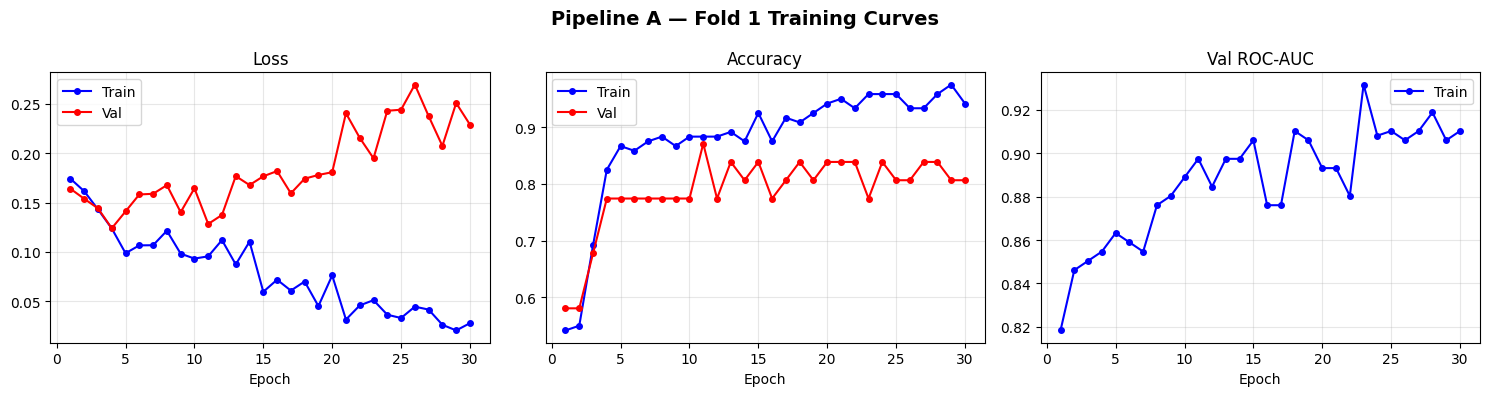

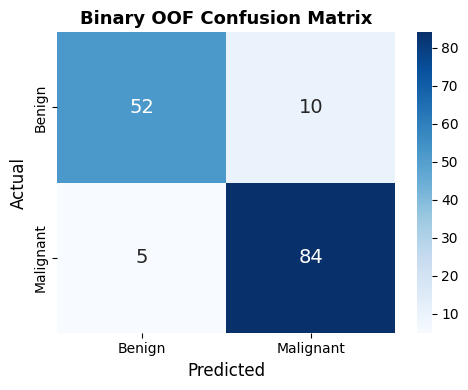

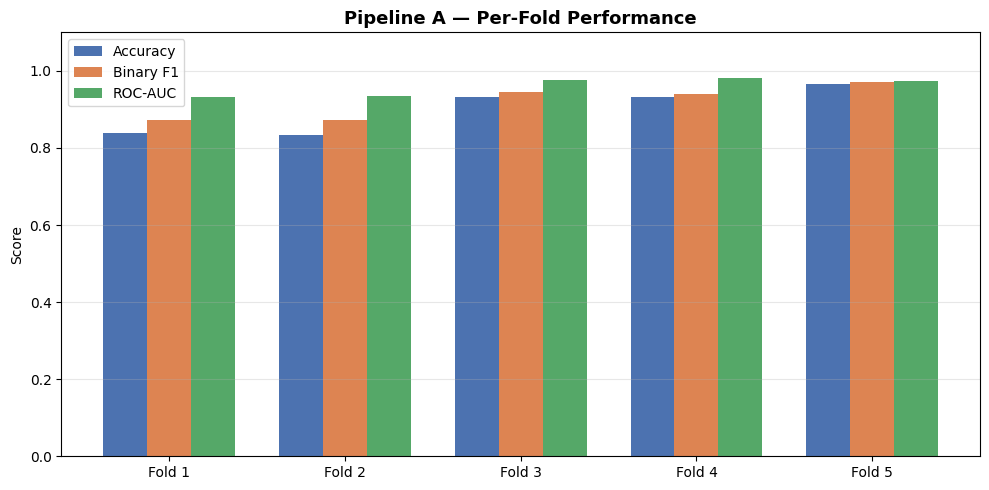

In [8]:
# ── OOF aggregation ─────────────────────────────────────────────────
all_labels_a = np.concatenate([r["labels"] for r in fold_results_a])
all_preds_a  = np.concatenate([r["preds"]  for r in fold_results_a])
all_probs_a  = np.concatenate([r["probs"]  for r in fold_results_a])

keys_a = ["acc", "f1", "auc"]
agg_a  = {k: [r["metrics"][k] for r in fold_results_a] for k in keys_a}

print("=" * 60); print(" PIPELINE A - CROSS-VALIDATION SUMMARY"); print("=" * 60)
for k in keys_a:
    vals = [v for v in agg_a[k] if not math.isnan(v)]
    if vals:
        print(f"  {k.upper():8s}: {np.mean(vals):.4f} +/- {np.std(vals):.4f}")

final_acc_a = accuracy_score(all_labels_a, all_preds_a)
final_f1_a  = f1_score(all_labels_a, all_preds_a, average='binary', zero_division=0)
try:
    final_auc_a = roc_auc_score(all_labels_a, all_probs_a)
except Exception:
    final_auc_a = float('nan')

print("\nOOF Classification Report:")
print(classification_report(all_labels_a, all_preds_a,
      target_names=["Benign/Unknown", "Malignant"], digits=4, zero_division=0))
print("=" * 58)
print(" PIPELINE A — OOF FINAL METRICS")
print(f"  Accuracy : {final_acc_a:.4f}  ({final_acc_a*100:.2f}%)")
print(f"  F1 Score : {final_f1_a:.4f}")
print("  ROC-AUC  :", f"{final_auc_a:.4f}" if not math.isnan(final_auc_a) else "N/A")
print("=" * 58)

# Training curves (fold 1)
h = fold_results_a[0]["history"]
epochs = [x["epoch"] for x in h]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Pipeline A — Fold 1 Training Curves", fontsize=14, fontweight="bold")
for ax, (tk, vk, lbl) in zip(axes, [
    ("tr_loss", "vl_loss", "Loss"),
    ("tr_acc",  "vl_acc",  "Accuracy"),
    ("vl_auc",  "vl_auc",  "Val ROC-AUC"),
]):
    ax.plot(epochs, [x[tk] for x in h], "b-o", ms=4, label="Train")
    if vk != tk:
        ax.plot(epochs, [x[vk] for x in h], "r-o", ms=4, label="Val")
    ax.set_title(lbl); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_A, "training_curves_binary.png"), dpi=150)
plt.show()

# OOF confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm_a = confusion_matrix(all_labels_a, all_preds_a, labels=[0, 1])
sns.heatmap(cm_a, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"],
            ax=ax, annot_kws={"size": 14})
ax.set_xlabel("Predicted", fontsize=12); ax.set_ylabel("Actual", fontsize=12)
ax.set_title("Binary OOF Confusion Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_A, "cm_binary_oof.png"), dpi=150)
plt.show()

# Per-fold bar
x = np.arange(len(fold_results_a)); w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, [r["metrics"]["acc"] for r in fold_results_a], w, label="Accuracy",  color="#4C72B0")
ax.bar(x,     [r["metrics"]["f1"]  for r in fold_results_a], w, label="Binary F1", color="#DD8452")
ax.bar(x + w, [r["metrics"]["auc"] for r in fold_results_a], w, label="ROC-AUC",  color="#55A868")
ax.set_xticks(x); ax.set_xticklabels([f"Fold {r['fold']}" for r in fold_results_a])
ax.set_ylabel("Score"); ax.set_title("Pipeline A — Per-Fold Performance", fontsize=13, fontweight="bold")
ax.legend(); ax.set_ylim(0, 1.1); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_A, "per_fold_a.png"), dpi=150)
plt.show()

## A5. Save Pipeline A models (pkl + JSON)


In [9]:
import joblib

PKL_DIR_A   = OUTPUT_DIR_A
JSON_PATH_A = os.path.join(PKL_DIR_A, "pipeline_a_params.json")

for r in fold_results_a:
    fold     = r["fold"]
    pkl_path = os.path.join(PKL_DIR_A, f"pipeline_a_fold{fold}.pkl")
    bundle = {
        "model_state_dict": {k: v.cpu() for k, v in r["model"].state_dict().items()},
        "feature_cols":     FEATURE_COLS_A,
        "n_tab":            len(FEATURE_COLS_A),
        "in_channels":      IN_CHANNELS_A,
        "embed_dim":        EMBED_DIM_A,
        "threshold":        r["threshold"],
        "scaler":           r["scaler"],
        "med":              r["med"].to_dict() if hasattr(r["med"], 'to_dict') else dict(r["med"]),
        "target_spacing":   list(TARGET_SPACING_A),
        "target_shape":     list(TARGET_SHAPE_A),
        "hu_min":           HU_MIN_A,   "hu_max":      HU_MAX_A,
        "hu_lung_min":      HU_LUNG_MIN_A, "hu_lung_max": HU_LUNG_MAX_A,
        "use_dual_channel": USE_DUAL_CHANNEL_A,
        "fold":             fold,
        "val_metrics":      {k: float(v) for k, v in r["metrics"].items()},
    }
    joblib.dump(bundle, pkl_path, compress=3)
    print(f"  Saved fold {fold} pkl -> {pkl_path}")

params_a = {
    "model": {
        "architecture": (
            "FusionModel_A — ImgEnc_A(stem->l1->l2->l3->l4->Pool->LayerNorm->FC(256)) "
            "+ TabEnc_A(FC->BN->ReLU->Dropout->FC(64)) "
            "+ Classifier(FC(320->128->64->1))"
        ),
        "attention":       "CBAM (SE channel + CBAMSpatial k=7) in ResBlk_A from l2 onward",
        "in_channels":     IN_CHANNELS_A,
        "embed_dim":       EMBED_DIM_A,
        "dual_channel":    USE_DUAL_CHANNEL_A,
    },
    "preprocessing": {
        "target_spacing": list(TARGET_SPACING_A),
        "target_shape":   list(TARGET_SHAPE_A),
        "hu_min": HU_MIN_A, "hu_max": HU_MAX_A,
        "hu_lung_min": HU_LUNG_MIN_A, "hu_lung_max": HU_LUNG_MAX_A,
        "channels": "ch0=standard HU window, ch1=lung HU window",
    },
    "training": {
        "strategy":    f"StratifiedKFold(n_splits={N_FOLDS_A}, shuffle=True)",
        "loss":        f"BinaryFocalLoss(gamma={FOCAL_GAMMA_A}, pos_weight={pos_w_a:.3f})",
        "optimizer":   f"AdamW(lr={LR_A}, weight_decay={WEIGHT_DECAY_A})",
        "scheduler":   f"CosineAnnealingLR(T_max={EPOCHS_A}, eta_min={LR_MIN_A})",
        "grad_clip":   1.0,
        "patience":    PATIENCE_A,
        "epochs":      EPOCHS_A,
        "batch_size":  BATCH_SIZE_A,
        "mixed_precision": USE_AMP_A,
    },
    "inference": {
        "threshold_tuning": TUNE_THRESH_A,
        "ensemble_strategy": "average sigmoid probabilities across folds",
    },
    "per_fold_val_metrics": {
        f"fold_{r['fold']}": {k: float(v) for k, v in r["metrics"].items()}
        for r in fold_results_a
    },
    "oof_metrics": {
        "accuracy": float(final_acc_a),
        "f1":       float(final_f1_a),
        "roc_auc":  float(final_auc_a) if not math.isnan(final_auc_a) else None,
    },
}
with open(JSON_PATH_A, "w") as f:
    json.dump(params_a, f, indent=2)
print(f"Saved JSON -> {JSON_PATH_A}")

# Sanity check: reload fold 1
b1_a = joblib.load(os.path.join(PKL_DIR_A, "pipeline_a_fold1.pkl"))
chk  = FusionModel_A(b1_a["n_tab"], b1_a["in_channels"]).to(device)
chk.load_state_dict(b1_a["model_state_dict"])
chk.eval()
with torch.no_grad():
    dummy_img = torch.zeros(1, IN_CHANNELS_A, *TARGET_SHAPE_A, device=device)
    dummy_tab = torch.zeros(1, b1_a["n_tab"], device=device)
    out_chk   = torch.sigmoid(chk(dummy_img, dummy_tab)).item()
print(f"Sanity check fold 1 — prob(malignant)={out_chk:.6f}")
print("Pipeline A artefacts saved.")

  Saved fold 1 pkl -> lidc_output_binary\pipeline_a_fold1.pkl
  Saved fold 2 pkl -> lidc_output_binary\pipeline_a_fold2.pkl
  Saved fold 3 pkl -> lidc_output_binary\pipeline_a_fold3.pkl
  Saved fold 4 pkl -> lidc_output_binary\pipeline_a_fold4.pkl
  Saved fold 5 pkl -> lidc_output_binary\pipeline_a_fold5.pkl
Saved JSON -> lidc_output_binary\pipeline_a_params.json
Sanity check fold 1 — prob(malignant)=0.918261
Pipeline A artefacts saved.


---
# Pipeline B — Multiclass Classification and Segmentation

Three-class classification: Benign/Unknown · Primary Lung Cancer · Metastatic

## B1. Configuration

In [10]:
class Config:
    EXCEL_PATH   = r"Data/tcia-diagnosis-data-2012-04-20.xls"
    DICOM_ROOT   = r"Data/manifest-1600709154662/LIDC-IDRI"
    OUTPUT_DIR   = "lidc_output"

    PATIENT_ID_COL   = "TCIA Patient ID"
    LABEL_SOURCE_COL = (
        "Diagnosis at the Patient Level\n0=Unknown\n"
        "1=benign or non-malignant disease\n2= malignant, primary lung cancer\n"
        "3 = malignant metastatic\n"
    )
    LABEL_MAP   = {0: 0, 1: 0, 2: 1, 3: 2}
    NUM_CLASSES = 3
    CLASS_NAMES = ["Benign/Unknown", "Primary Lung Ca", "Metastatic"]

    # ── HU windows ────────────────────────────────────────────────────
    HU_MIN = -1000; HU_MAX = 400
    HU_LUNG_MIN = -600; HU_LUNG_MAX = 1500
    USE_DUAL_CHANNEL = True; IN_CHANNELS = 2

    # ── geometry ──────────────────────────────────────────────────────
    TARGET_SPACING  = (2.0, 1.0, 1.0)
    TARGET_SHAPE    = (64, 128, 128)
    CONSENSUS_LEVEL = 0.5

    # ── segmentation patch ────────────────────────────────────────────
    PATCH_SHAPE    = (32, 64, 64)
    FG_SAMPLE_PROB = 0.8

    # ── augmentation ──────────────────────────────────────────────────
    AUG_FLIP_PROB      = 0.5
    AUG_ROTATE_PROB    = 0.5; AUG_ROTATE_MAX    = 15.0
    AUG_NOISE_PROB     = 0.3; AUG_NOISE_STD     = 0.02
    AUG_GAMMA_PROB     = 0.3; AUG_GAMMA         = (0.75, 1.25)
    AUG_ELASTIC_PROB   = 0.2; AUG_ELASTIC_ALPHA = 10.0; AUG_ELASTIC_SIGMA = 2.0
    AUG_MIXUP_PROB     = 0.4; AUG_MIXUP_ALPHA   = 0.4   

    # ── model ─────────────────────────────────────────────────────────
    CH = [16, 32, 64, 128, 256]; EMBED_DIM = 256
    N_RADIOMICS = 10                                    

    # ── training ──────────────────────────────────────────────────────
    BATCH_SIZE   = 2
    EPOCHS       = 70
    WARMUP_EPOCHS = 5                               
    LR           = 2e-4
    LR_MIN       = 1e-6
    WEIGHT_DECAY = 1e-4
    NUM_WORKERS  = 0
    USE_AMP      = True
    SEED         = 42
    N_FOLDS      = 5
    PATIENCE     = 12                                
    VAL_SIZE     = 0.20

    USE_FOCAL        = True
    FOCAL_GAMMA      = 2.0
    LABEL_SMOOTHING  = 0.1                             
    TUNE_THRESHOLDS  = True
    MODEL_NAME       = "best_lidc_model"

    SEG_LOSS_WEIGHT  = 0.4                             
    SEG_THRESHOLD    = 0.5

    USE_TTA          = True                              
    USE_SAMPLER      = True                              

C = Config()
Path(C.OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
set_seed(C.SEED)
print(f"Config ready. Output: {C.OUTPUT_DIR}")
print(f"Full vol: {C.TARGET_SHAPE}  |  Patch: {C.PATCH_SHAPE}  |  Radiomics: {C.N_RADIOMICS} features")
print(f"Mixup={C.AUG_MIXUP_PROB}  LabelSmooth={C.LABEL_SMOOTHING}  Warmup={C.WARMUP_EPOCHS}ep  TTA={C.USE_TTA}")

Config ready. Output: lidc_output
Full vol: (64, 128, 128)  |  Patch: (32, 64, 64)  |  Radiomics: 10 features
Mixup=0.4  LabelSmooth=0.1  Warmup=5ep  TTA=True


## B2. Preprocessing and augmentation

In [11]:
def preprocess_ct_multi(dicom_dir, patient_id=None):
    """
    Returns (img [C, Z, Y, X], mask [Z, Y, X]).
    img  — full volume (classifier input).
    mask — full-volume binary nodule mask (used for patch extraction).
    """
    vol, spacing = load_dicom_series(dicom_dir)
    vol  = _resample(vol, spacing, C.TARGET_SPACING)
    vol  = _crop_pad(vol, C.TARGET_SHAPE)
    std  = _clip_norm(vol, C.HU_MIN,      C.HU_MAX)
    lung = _clip_norm(vol, C.HU_LUNG_MIN, C.HU_LUNG_MAX)
    img  = np.stack([std, lung], axis=0) if C.USE_DUAL_CHANNEL else std[np.newaxis]

    mask = np.zeros(C.TARGET_SHAPE, dtype=np.float32)
    if patient_id is not None:
        mask = build_consensus_mask(
            patient_id, C.TARGET_SHAPE, C.TARGET_SPACING,
            clevel=C.CONSENSUS_LEVEL
        )
    return img.astype(np.float32), mask


# ── V4: hand-crafted radiomics from consensus mask ────────────────
def extract_radiomics(vol_std, mask):
    """
    Extract 10 shape+intensity radiomics features from the nodule region.
    Based on Armato et al. 2011 LIDC feature set and Shen et al. 2019.
    Returns a float32 array of length C.N_RADIOMICS (10).
    All features are normalised to [-1, 1] range so they don't need
    an external scaler (fold-level scaling still applied in training).
    """
    feats = np.zeros(C.N_RADIOMICS, dtype=np.float32)
    bin_mask = (mask > 0.5)
    n_vox = bin_mask.sum()

    if n_vox < 1:
        return feats   # all zeros for no-nodule patients

    # voxel volume in mm^3 (spacing is Z,Y,X in mm)
    vox_vol = C.TARGET_SPACING[0] * C.TARGET_SPACING[1] * C.TARGET_SPACING[2]

    # ── shape features ────────────────────────────────────────────────
    volume_mm3 = n_vox * vox_vol                          # f0

    # surface area approximation via voxel face counting
    padded = np.pad(bin_mask, 1, mode='constant')
    surface = (
        (bin_mask & ~padded[2:,  1:-1, 1:-1]).sum() +
        (bin_mask & ~padded[:-2, 1:-1, 1:-1]).sum() +
        (bin_mask & ~padded[1:-1, 2:,  1:-1]).sum() +
        (bin_mask & ~padded[1:-1, :-2, 1:-1]).sum() +
        (bin_mask & ~padded[1:-1, 1:-1, 2:]).sum()  +
        (bin_mask & ~padded[1:-1, 1:-1, :-2]).sum()
    ) * vox_vol**(2/3)
    surface_area = float(surface)                         # f1

    # sphericity = (pi^(1/3) * (6*V)^(2/3)) / SA
    sphericity = (np.pi**(1/3) * (6 * volume_mm3)**(2/3)) / (surface_area + 1e-8)  # f2

    # compactness = V / (SA^(3/2))
    compactness = volume_mm3 / (surface_area**1.5 + 1e-8)  # f3

    # bounding box elongation and flatness
    coords = np.argwhere(bin_mask)
    bb_min = coords.min(axis=0); bb_max = coords.max(axis=0)
    dims   = np.sort(bb_max - bb_min + 1)[::-1].astype(float)  # largest first
    elongation = dims[1] / (dims[0] + 1e-8)              # f4  (0..1)
    flatness   = dims[2] / (dims[0] + 1e-8)              # f5  (0..1)

    # surface-to-volume ratio
    sv_ratio = surface_area / (volume_mm3 + 1e-8)        # f6

    # solidity = V / convex_hull_V  (approx via bounding box)
    bb_vol   = float(dims[0] * dims[1] * dims[2]) * vox_vol
    solidity = volume_mm3 / (bb_vol + 1e-8)              # f7

    # ── intensity features (on standard HU channel) ───────────────────
    nodule_hu = vol_std[bin_mask]                         # normalised [0,1]
    mean_hu   = float(nodule_hu.mean())                   # f8
    std_hu    = float(nodule_hu.std())                    # f9

    feats = np.array([
        np.log1p(volume_mm3) / 15.0,      # log-scale, approx [-1,1]
        np.log1p(surface_area) / 12.0,
        np.clip(sphericity, 0, 2) - 1.0,  # centered
        np.clip(compactness * 100, 0, 2) - 1.0,
        elongation * 2 - 1.0,
        flatness   * 2 - 1.0,
        np.clip(sv_ratio / 5.0, 0, 2) - 1.0,
        solidity   * 2 - 1.0,
        mean_hu    * 2 - 1.0,             # [0,1] -> [-1,1]
        std_hu     * 4 - 1.0,
    ], dtype=np.float32)
    return np.clip(feats, -3.0, 3.0)     # hard clip for outliers


def extract_patch(img, mask, training=False):
    pZ, pY, pX = C.PATCH_SHAPE
    _, Z, Y, X  = img.shape

    fg = np.argwhere(mask > 0.5)
    bg = np.argwhere(mask < 0.5)

    if training:
        use_fg = (len(fg) > 0) and (random.random() < C.FG_SAMPLE_PROB)
        if use_fg:
            cz, cy, cx = fg[random.randint(0, len(fg) - 1)]
        elif len(bg) > 0:
            cz, cy, cx = bg[random.randint(0, len(bg) - 1)]
        else:
            cz, cy, cx = Z // 2, Y // 2, X // 2
    else:
        cz, cy, cx = (fg.mean(axis=0).astype(int) if len(fg) > 0
                      else np.array([Z // 2, Y // 2, X // 2]))

    z0 = int(np.clip(cz - pZ // 2, 0, max(Z - pZ, 0)))
    y0 = int(np.clip(cy - pY // 2, 0, max(Y - pY, 0)))
    x0 = int(np.clip(cx - pX // 2, 0, max(X - pX, 0)))
    z1, y1, x1 = z0 + pZ, y0 + pY, x0 + pX

    img_p  = img[:, z0:z1, y0:y1, x0:x1]
    mask_p = mask[   z0:z1, y0:y1, x0:x1]

    if img_p.shape[1:] != tuple(C.PATCH_SHAPE):
        tmp_i = np.zeros((img.shape[0], *C.PATCH_SHAPE), dtype=np.float32)
        tmp_m = np.zeros(C.PATCH_SHAPE, dtype=np.float32)
        dz, dy, dx = img_p.shape[1], img_p.shape[2], img_p.shape[3]
        tmp_i[:, :dz, :dy, :dx] = img_p
        tmp_m[:dz, :dy, :dx]    = mask_p
        img_p, mask_p = tmp_i, tmp_m

    return img_p.astype(np.float32), mask_p.astype(np.float32)


def elastic_deform(vol, alpha, sigma):
    C_, Z, Y, X = vol.shape
    dx = gaussian_filter(np.random.randn(Z, Y, X).astype(np.float32), sigma) * alpha
    dy = gaussian_filter(np.random.randn(Z, Y, X).astype(np.float32), sigma) * alpha
    dz = gaussian_filter(np.random.randn(Z, Y, X).astype(np.float32), sigma) * alpha
    zz, yy, xx = np.meshgrid(np.arange(Z), np.arange(Y), np.arange(X), indexing="ij")
    cz = np.clip(zz + dz, 0, Z - 1).ravel()
    cy = np.clip(yy + dy, 0, Y - 1).ravel()
    cx = np.clip(xx + dx, 0, X - 1).ravel()
    out = np.zeros_like(vol)
    for c in range(C_):
        out[c] = map_coordinates(vol[c], [cz, cy, cx], order=1, mode="reflect").reshape(Z, Y, X)
    return out


def augment_multi(vol, mask):
    """Augment full-volume img + mask before patch extraction."""
    v = vol.copy(); m = mask.copy()
    for img_ax, msk_ax in [(3, 2), (2, 1), (1, 0)]:
        if random.random() < C.AUG_FLIP_PROB:
            v = np.flip(v, img_ax).copy()
            m = np.flip(m, msk_ax).copy()
    if random.random() < C.AUG_ROTATE_PROB:
        ang = random.uniform(-C.AUG_ROTATE_MAX, C.AUG_ROTATE_MAX)
        for ch in range(v.shape[0]):
            v[ch] = rotate(v[ch], ang, axes=(1, 2), reshape=False, order=1, mode="reflect")
        m = rotate(m, ang, axes=(1, 2), reshape=False, order=0, mode="reflect")
    if random.random() < C.AUG_NOISE_PROB:
        v = np.clip(v + np.random.randn(*v.shape).astype(np.float32) * C.AUG_NOISE_STD, 0, 1)
    if random.random() < C.AUG_GAMMA_PROB:
        v = np.clip(v ** random.uniform(*C.AUG_GAMMA), 0, 1)
    if random.random() < C.AUG_ELASTIC_PROB:
        v = np.clip(elastic_deform(v, C.AUG_ELASTIC_ALPHA, C.AUG_ELASTIC_SIGMA), 0, 1)
        m4 = m[np.newaxis]
        m4 = elastic_deform(m4, C.AUG_ELASTIC_ALPHA, C.AUG_ELASTIC_SIGMA)
        m  = (m4[0] > 0.5).astype(np.float32)
    return v.astype(np.float32), m.astype(np.float32)


print("Preprocessing, radiomics, patch extraction, and augmentation defined.")

Preprocessing, radiomics, patch extraction, and augmentation defined.


## B3. Dataset

In [12]:
class LIDCDataset(Dataset):
    def __init__(self, df, training=False):
        self.df       = df.reset_index(drop=True)
        self.training = training

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row["label"])
        pid   = row["patient_id"]

        try:
            img, mask = preprocess_ct_multi(row["dicom_dir"], patient_id=pid)
        except Exception as e:
            log.warning(f"Load failed {row['dicom_dir']}: {e}")
            img  = np.zeros((C.IN_CHANNELS, *C.TARGET_SHAPE), dtype=np.float32)
            mask = np.zeros(C.TARGET_SHAPE, dtype=np.float32)

        # V4: extract radiomics from the standard channel + mask
        radio = extract_radiomics(img[0], mask)   # [N_RADIOMICS]

        if self.training:
            img, mask = augment_multi(img, mask)

        img_patch, mask_patch = extract_patch(img, mask, training=self.training)

        return {
            "image":       torch.tensor(img,        dtype=torch.float32),
            "image_patch": torch.tensor(img_patch,  dtype=torch.float32),
            "mask":        torch.tensor(mask_patch, dtype=torch.float32).unsqueeze(0),
            "radiomics":   torch.tensor(radio,      dtype=torch.float32),  # V4
            "label":       torch.tensor(label, dtype=torch.long),
            "patient_id":  pid,
        }


# WeightedRandomSampler — oversample minority classes per-batch
def make_weighted_sampler(df):
    """Returns a WeightedRandomSampler that balances class frequency.
    Based on He et al. 2009 class-balanced sampling."""
    labels = df["label"].values
    counts = np.bincount(labels, minlength=C.NUM_CLASSES).astype(float)
    weight_per_class = 1.0 / np.maximum(counts, 1)
    sample_weights   = weight_per_class[labels]
    from torch.utils.data import WeightedRandomSampler
    return WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.float32),
        num_samples=len(df),
        replacement=True
    )


print("LIDCDataset + WeightedRandomSampler defined.")

LIDCDataset + WeightedRandomSampler defined.


## B4. Model architecture

**Classifier**: 3D ResNet with SE channel attention + CBAM spatial attention.

**Segmentation**: Lightweight 3D U-Net with skip connections.


In [26]:
# ── Shared attention blocks ──────────────────────────────────────
class SEBlock(nn.Module):
    def __init__(self, ch, r=8):
        super().__init__()
        h = max(ch // r, 4)
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.fc = nn.Sequential(nn.Linear(ch, h), nn.ReLU(True), nn.Linear(h, ch), nn.Sigmoid())
    def forward(self, x):
        b, c = x.shape[:2]
        return x * self.fc(self.pool(x).view(b, c)).view(b, c, 1, 1, 1)


class CBAMSpatial(nn.Module):
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv3d(2, 1, k, padding=k // 2, bias=False)
    def forward(self, x):
        w = torch.sigmoid(self.conv(torch.cat([x.mean(1, True), x.max(1).values.unsqueeze(1)], 1)))
        return x * w


class CBAM(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.se = SEBlock(ch); self.sp = CBAMSpatial()
    def forward(self, x):
        return self.sp(self.se(x))


class ResBlk(nn.Module):
    def __init__(self, ic, oc, s=1, cbam=True):
        super().__init__()
        self.c1 = nn.Conv3d(ic, oc, 3, s, 1, bias=False); self.b1 = nn.BatchNorm3d(oc)
        self.c2 = nn.Conv3d(oc, oc, 3, 1, 1, bias=False); self.b2 = nn.BatchNorm3d(oc)
        self.at = CBAM(oc) if cbam else nn.Identity()
        self.dn = (nn.Sequential(nn.Conv3d(ic, oc, 1, s, bias=False), nn.BatchNorm3d(oc))
                   if s != 1 or ic != oc else nn.Identity())
        self.act = nn.ReLU(True)
    def forward(self, x):
        return self.act(self.at(self.b2(self.c2(self.act(self.b1(self.c1(x)))))) + self.dn(x))


# ── Encoder (shared between classifier and U-Net encoder path) ────
class Encoder3D(nn.Module):
    def __init__(self, in_ch=2, out=256):
        super().__init__()
        ch = C.CH
        self.stem = nn.Sequential(nn.Conv3d(in_ch, ch[0], 5, 2, 2, bias=False),
                                   nn.BatchNorm3d(ch[0]), nn.ReLU(True))
        self.s1 = nn.Sequential(ResBlk(ch[0], ch[1], 2, False), ResBlk(ch[1], ch[1], 1, False))
        self.s2 = nn.Sequential(ResBlk(ch[1], ch[2], 2),        ResBlk(ch[2], ch[2]))
        self.s3 = nn.Sequential(ResBlk(ch[2], ch[3], 2),        ResBlk(ch[3], ch[3]))
        self.s4 = nn.Sequential(ResBlk(ch[3], ch[4], 2),        ResBlk(ch[4], ch[4]))
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(ch[4], out),
                                   nn.LayerNorm(out), nn.ReLU(True), nn.Dropout(0.3))
    def forward(self, x):
        return self.head(self.pool(self.s4(self.s3(self.s2(self.s1(self.stem(x)))))))


# ── V4: Radiomics MLP fused with image embedding ─────────────────
class RadiomicsMLP(nn.Module):
    """Small MLP that maps N_RADIOMICS features → 64-dim embedding.
    Architecture follows Shen et al. 2019 auxiliary feature branch."""
    def __init__(self, n_in=10, out=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 64), nn.LayerNorm(64),   nn.ReLU(True), nn.Dropout(0.2),
            nn.Linear(64, out),  nn.ReLU(True)
        )
    def forward(self, x):
        return self.net(x)


class LIDCClassifier(nn.Module):
    """3D ResNet-SE+CBAM encoder fused with radiomics MLP."""
    def __init__(self, n_cls=3, in_ch=2, emb=256, n_radio=10):
        super().__init__()
        self.enc   = Encoder3D(in_ch, emb)
        self.radio = RadiomicsMLP(n_radio, 64)
        self.cls   = nn.Sequential(
            nn.Linear(emb + 64, 128), nn.ReLU(True), nn.Dropout(0.3),
            nn.Linear(128, 64),       nn.ReLU(True), nn.Dropout(0.2),
            nn.Linear(64, n_cls)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, (nn.BatchNorm3d, nn.LayerNorm)):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x, radio):
        img_emb   = self.enc(x)
        radio_emb = self.radio(radio)
        return self.cls(torch.cat([img_emb, radio_emb], dim=1))


# ── V4: Attention Gate for U-Net skip connections (Oktay 2018) ────
class AttentionGate(nn.Module):
    """Soft attention gate on skip connection.
    g = gating signal (from deeper layer), x = skip feature.
    Ref: Oktay et al. 2018 Attention U-Net."""
    def __init__(self, f_g, f_x, f_int):
        super().__init__()
        self.Wg = nn.Sequential(nn.Conv3d(f_g, f_int, 1, bias=False), nn.BatchNorm3d(f_int))
        self.Wx = nn.Sequential(nn.Conv3d(f_x, f_int, 1, bias=False), nn.BatchNorm3d(f_int))
        self.psi = nn.Sequential(nn.Conv3d(f_int, 1, 1, bias=False), nn.BatchNorm3d(1), nn.Sigmoid())
        self.relu = nn.ReLU(True)

    def forward(self, g, x):
        if g.shape[2:] != x.shape[2:]:
            g = F.interpolate(g, size=x.shape[2:], mode='trilinear', align_corners=False)
        alpha = self.psi(self.relu(self.Wg(g) + self.Wx(x)))
        return x * alpha


def _dbl_conv(ic, oc):
    return nn.Sequential(
        nn.Conv3d(ic, oc, 3, 1, 1, bias=False), nn.BatchNorm3d(oc), nn.ReLU(True),
        nn.Conv3d(oc, oc, 3, 1, 1, bias=False), nn.BatchNorm3d(oc), nn.ReLU(True),
    )


class UNet3D(nn.Module):
    """3D Attention U-Net for nodule segmentation (Oktay 2018)."""
    def __init__(self, in_ch=2):
        super().__init__()
        f = [16, 32, 64, 128]
        # encoder
        self.e0 = _dbl_conv(in_ch, f[0]); self.p0 = nn.MaxPool3d(2)
        self.e1 = _dbl_conv(f[0],  f[1]); self.p1 = nn.MaxPool3d(2)
        self.e2 = _dbl_conv(f[1],  f[2]); self.p2 = nn.MaxPool3d(2)
        self.bot = _dbl_conv(f[2], f[3])
        # attention gates on skip connections
        self.ag2 = AttentionGate(f[3], f[2], f[2] // 2)
        self.ag1 = AttentionGate(f[2], f[1], f[1] // 2)
        self.ag0 = AttentionGate(f[1], f[0], f[0] // 2)
        # decoder
        self.u2 = nn.ConvTranspose3d(f[3], f[2], 2, 2); self.d2 = _dbl_conv(f[2]*2, f[2])
        self.u1 = nn.ConvTranspose3d(f[2], f[1], 2, 2); self.d1 = _dbl_conv(f[1]*2, f[1])
        self.u0 = nn.ConvTranspose3d(f[1], f[0], 2, 2); self.d0 = _dbl_conv(f[0]*2, f[0])
        self.out = nn.Conv3d(f[0], 1, 1)

    def forward(self, x):
        # ── encoder ──────────────────────────────────────────────────
        s0 = self.e0(x)               # [B, 16, Z,   Y,   X  ]
        s1 = self.e1(self.p0(s0))     # [B, 32, Z/2, Y/2, X/2]
        s2 = self.e2(self.p1(s1))     # [B, 64, Z/4, Y/4, X/4]
        b  = self.bot(self.p2(s2))    # [B,128, Z/8, Y/8, X/8]
        # ── decoder with attention gates ─────────────────────────────
        # Level 2: gate s2 using bottleneck b as query
        up2 = self.u2(b)              # [B, 64, Z/4, Y/4, X/4]
        s2g = self.ag2(b,  s2)        # ag2: f_g=128, f_x=64
        x2  = self.d2(torch.cat([up2, s2g], 1))  # [B, 64, Z/4, ...]
        # Level 1: gate s1 using x2 (64ch) as query
        up1 = self.u1(x2)             # [B, 32, Z/2, Y/2, X/2]
        s1g = self.ag1(x2, s1)        # ag1: f_g=64,  f_x=32
        x1  = self.d1(torch.cat([up1, s1g], 1))  # [B, 32, Z/2, ...]
        # Level 0: gate s0 using x1 (32ch) as query
        up0 = self.u0(x1)             # [B, 16, Z,   Y,   X  ]
        s0g = self.ag0(x1, s0)        # ag0: f_g=32,  f_x=16
        x0  = self.d0(torch.cat([up0, s0g], 1))  # [B, 16, Z,   ...]
        return self.out(x0)


# ── FocalLoss with label smoothing (Müller 2019) ─────────────
class FocalLoss(nn.Module):
    def __init__(self, w, g=2.0, smoothing=0.0, num_classes=3):
        super().__init__()
        self.g = g; self.w = w
        self.smoothing   = smoothing
        self.num_classes = num_classes

    def forward(self, logits, targets):
        log_p = F.log_softmax(logits, 1)
        p     = torch.exp(log_p)

        if self.smoothing > 0:
            with torch.no_grad():
                smooth_targets = torch.full_like(logits, self.smoothing / self.num_classes)
                smooth_targets.scatter_(1, targets.unsqueeze(1),
                                        1.0 - self.smoothing + self.smoothing / self.num_classes)
            ce   = -(smooth_targets * log_p).sum(dim=1)
            pt   = p.gather(1, targets.unsqueeze(1)).squeeze(1)
            loss = ((1 - pt) ** self.g) * self.w[targets] * ce
        else:
            g_   = log_p.gather(1, targets.unsqueeze(1)).squeeze(1)
            pt   = p.gather(1, targets.unsqueeze(1)).squeeze(1)
            loss = (-(1 - pt) ** self.g * self.w[targets] * g_)

        return loss.mean()


def dice_loss(pred_logits, target, smooth=1.0):
    pred   = torch.sigmoid(pred_logits)
    pred_f = pred.view(-1); tgt_f = target.view(-1)
    inter  = (pred_f * tgt_f).sum()
    dice   = 1 - (2 * inter + smooth) / (pred_f.sum() + tgt_f.sum() + smooth)
    bce    = F.binary_cross_entropy_with_logits(pred_logits, target)
    return 0.5 * dice + 0.5 * bce


def dice_score(pred_logits, target, threshold=0.5):
    pred   = (torch.sigmoid(pred_logits) >= threshold).float()
    pred_f = pred.view(-1); tgt_f = target.view(-1)
    inter  = (pred_f * tgt_f).sum()
    return ((2 * inter + 1e-6) / (pred_f.sum() + tgt_f.sum() + 1e-6)).item()


print("Attention U-Net + RadiomicsMLP + FocalLoss(label_smooth) defined.")

Attention U-Net + RadiomicsMLP + FocalLoss(label_smooth) defined.


## B5. Training helpers and metrics

In [27]:
def compute_metrics(labels, preds, probs, nc):
    row_sums = probs.sum(axis=1, keepdims=True)
    probs_n  = probs / np.where(row_sums == 0, 1.0, row_sums)
    try:
        auc = (roc_auc_score(labels, probs_n, multi_class="ovr", average="macro",
                             labels=list(range(nc)))
               if len(np.unique(labels)) > 1 else float("nan"))
    except Exception:
        auc = float("nan")
    return {
        "acc":    accuracy_score(labels, preds),
        "f1_mac": f1_score(labels, preds, average="macro",    zero_division=0),
        "f1_wt":  f1_score(labels, preds, average="weighted", zero_division=0),
        "auc":    auc,
    }


def tune_thresholds(probs, labels, nc):
    import itertools
    best_t = np.array([0.5] * nc); best_f1 = 0.0
    for combo in itertools.product(np.arange(0.2, 0.81, 0.05), repeat=nc):
        t  = np.array(combo)
        p  = (probs / (t + 1e-9)).argmax(1)
        f1 = f1_score(labels, p, average="macro", zero_division=0)
        if f1 > best_f1:
            best_f1 = f1; best_t = t
    return best_t


# Mixup for 3D volumes + labels (Zhang et al. 2018)
def mixup_batch(imgs, radios, labels, alpha=0.4, nc=3):
    """Mix two random samples. Returns mixed imgs, mixed soft labels.
    Works with long integer labels by converting to one-hot first."""
    if alpha <= 0 or random.random() > C.AUG_MIXUP_PROB:
        # no mixup — convert labels to one-hot for consistent return type
        oh = F.one_hot(labels, nc).float()
        return imgs, radios, oh

    lam = float(np.random.beta(alpha, alpha))
    B   = imgs.size(0)
    idx = torch.randperm(B, device=imgs.device)

    mixed_imgs   = lam * imgs   + (1 - lam) * imgs[idx]
    mixed_radios = lam * radios + (1 - lam) * radios[idx]

    oh_a = F.one_hot(labels,      nc).float()
    oh_b = F.one_hot(labels[idx], nc).float()
    mixed_labels = lam * oh_a + (1 - lam) * oh_b   # soft targets

    return mixed_imgs, mixed_radios, mixed_labels


def focal_loss_soft(logits, soft_targets, w, g=2.0):
    """Focal loss for Mixup soft (one-hot blend) targets."""
    log_p = F.log_softmax(logits, 1)
    p     = torch.exp(log_p)
    # approximate focal weight from soft targets
    pt = (p * soft_targets).sum(dim=1)   # expected probability of correct class
    ce = -(soft_targets * log_p).sum(dim=1)
    # class weight: expectation over soft targets
    cw = (soft_targets * w.unsqueeze(0)).sum(dim=1)
    return ((1 - pt) ** g * cw * ce).mean()


def run_epoch_b(clf, seg, loader, crit_cls, optimizer=None, samp=None,
                training=True, epoch=0):
    clf.train() if training else clf.eval()
    seg.train() if training else seg.eval()
    losses_cls, losses_seg, losses_tot = [], [], []
    all_labels, all_probs, all_dice = [], [], []

    cw_t = crit_cls.w   # reuse stored class weights for mixup

    for batch in loader:
        imgs       = batch["image"].to(device, non_blocking=True)
        imgs_patch = batch["image_patch"].to(device, non_blocking=True)
        masks      = batch["mask"].to(device, non_blocking=True)
        labels     = batch["label"].to(device, non_blocking=True)
        radios     = batch["radiomics"].to(device, non_blocking=True)  # V4

        with torch.set_grad_enabled(training):
            with torch.amp.autocast("cuda", enabled=(C.USE_AMP and device.type == "cuda")):
                if training:
                    # V4: Mixup on image + radiomics
                    imgs_m, radios_m, soft_lbl = mixup_batch(
                        imgs, radios, labels, C.AUG_MIXUP_ALPHA, C.NUM_CLASSES
                    )
                    cls_logits = clf(imgs_m, radios_m)
                    seg_logits = seg(imgs_patch)   # seg uses un-mixed patch
                    loss_cls   = focal_loss_soft(cls_logits, soft_lbl, cw_t, C.FOCAL_GAMMA)
                else:
                    cls_logits = clf(imgs, radios)
                    seg_logits = seg(imgs_patch)
                    loss_cls   = crit_cls(cls_logits, labels)

                loss_seg = dice_loss(seg_logits, masks)
                loss     = loss_cls + C.SEG_LOSS_WEIGHT * loss_seg

            if training:
                optimizer.zero_grad(set_to_none=True)
                samp.scale(loss).backward()
                samp.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    list(clf.parameters()) + list(seg.parameters()), 1.0
                )
                samp.step(optimizer); samp.update()

        # always evaluate with hard labels
        with torch.no_grad():
            if training:
                eval_logits = clf(imgs, radios)   # re-forward without mixup for logging
            else:
                eval_logits = cls_logits
        probs_cpu = F.softmax(eval_logits.detach(), 1).cpu().numpy()
        all_probs.append(probs_cpu)
        all_labels.append(labels.detach().cpu().numpy())
        all_dice.append(dice_score(seg_logits.detach(), masks.detach()))
        losses_cls.append(loss_cls.item())
        losses_seg.append(loss_seg.item())
        losses_tot.append(loss.item())

    all_probs  = np.vstack(all_probs)
    all_labels = np.concatenate(all_labels).astype(int)
    all_preds  = all_probs.argmax(1)
    metrics    = compute_metrics(all_labels, all_preds, all_probs, C.NUM_CLASSES)
    metrics.update({
        "loss":     np.mean(losses_tot),
        "loss_cls": np.mean(losses_cls),
        "loss_seg": np.mean(losses_seg),
        "dice":     np.mean(all_dice),
        "probs":    all_probs,
        "labels":   all_labels,
        "preds":    all_preds,
    })
    return metrics


def _savefig(fig, name):
    fig.savefig(os.path.join(C.OUTPUT_DIR, name), bbox_inches="tight", dpi=150)
    plt.close(fig)


# Warm-up + Cosine scheduler (Goyal 2017)
class WarmupCosineScheduler:
    """Linear warm-up for `warmup_epochs`, then CosineAnnealing to LR_MIN."""
    def __init__(self, optimizer, warmup_epochs, total_epochs, lr_max, lr_min):
        self.opt = optimizer; self.wu = warmup_epochs
        self.T   = total_epochs; self.lr_max = lr_max; self.lr_min = lr_min
        self.ep  = 0

    def step(self):
        self.ep += 1
        if self.ep <= self.wu:
            lr = self.lr_max * self.ep / self.wu
        else:
            prog = (self.ep - self.wu) / max(self.T - self.wu, 1)
            lr   = self.lr_min + 0.5 * (self.lr_max - self.lr_min) * (1 + math.cos(math.pi * prog))
        for pg in self.opt.param_groups:
            pg['lr'] = lr

    def get_lr(self):
        return self.opt.param_groups[0]['lr']


# TTA — 8-flip ensemble at inference
def tta_predict(clf, imgs, radios, n_classes):
    """Average softmax over all 8 flip combinations (X, Y, Z axes).
    Ref: Wang et al. 2019 TTA for medical image segmentation/classification."""
    prob_sum = None
    for fz in [False, True]:
        for fy in [False, True]:
            for fx in [False, True]:
                v = imgs.clone()
                if fz: v = v.flip(2)   # Z axis
                if fy: v = v.flip(3)   # Y axis
                if fx: v = v.flip(4)   # X axis
                with torch.amp.autocast("cuda", enabled=(C.USE_AMP and device.type == "cuda")):
                    logits = clf(v, radios)
                p = F.softmax(logits, 1)
                prob_sum = p if prob_sum is None else prob_sum + p
    return (prob_sum / 8.0).cpu().numpy()


print("Training helpers, Mixup, WarmupCosine, TTA defined.")

Training helpers, Mixup, WarmupCosine, TTA defined.


## B6. Data loading

In [28]:
print("Reading Excel (Pipeline B)...")
ext = os.path.splitext(C.EXCEL_PATH)[-1].lower()
df_b = (pd.read_excel(C.EXCEL_PATH, engine="xlrd")
        if ext == ".xls" else pd.read_excel(C.EXCEL_PATH))

df_b["patient_id"] = df_b[C.PATIENT_ID_COL].astype(str).map(normalize_patient_id)
df_b["label"]      = df_b[C.LABEL_SOURCE_COL].map(
    lambda x: C.LABEL_MAP.get(int(x) if not pd.isna(x) else 0, 0)
)

print("Scanning DICOM tree (Pipeline B)...")
pts_b = build_patient_to_series_map(C.DICOM_ROOT)
df_b["dicom_dir"] = df_b["patient_id"].map(pts_b)

df_b = df_b.dropna(subset=["dicom_dir", "label"]).copy()
df_b["label"] = df_b["label"].astype(int)

print(f"  Matched: {len(df_b)} patients")
for cls, nm in enumerate(C.CLASS_NAMES):
    print(f"  Class {cls} - {nm}: {(df_b['label']==cls).sum()}")
if len(df_b) == 0:
    raise RuntimeError("Zero patients matched.")

print("Filtering patients with bad annotation clusters...")
n_before = len(df_b)
try:
    df_b["has_valid_cluster"] = df_b["patient_id"].apply(mask_has_nodule)
    n_bad = (~df_b["has_valid_cluster"]).sum()
    df_b  = df_b[df_b["has_valid_cluster"]].drop(columns=["has_valid_cluster"]).copy()
    print(f"  Removed {n_bad} patients with invalid clusters ({n_before} -> {len(df_b)})")
except Exception as e:
    print(f"  Cluster filter skipped (pylidc not configured?): {e}")

counts_b = np.array([(df_b["label"] == c).sum() for c in range(C.NUM_CLASSES)], dtype=float)
cw_b = counts_b.sum() / (C.NUM_CLASSES * np.maximum(counts_b, 1))
cw_b = cw_b / cw_b.sum() * C.NUM_CLASSES
print(f"  Class weights: {cw_b.round(3).tolist()}")

Reading Excel (Pipeline B)...
Scanning DICOM tree (Pipeline B)...
  Matched: 151 patients
  Class 0 - Benign/Unknown: 62
  Class 1 - Primary Lung Ca: 39
  Class 2 - Metastatic: 50
Filtering patients with bad annotation clusters...
  Removed 16 patients with invalid clusters (151 -> 135)
  Class weights: [0.814, 1.188, 0.999]


## B7. K-Fold training

In [ ]:
def train_fold_b(train_df, val_df, fold, cw):
    log.info(f"\n{'='*55}\n  FOLD {fold}  train={len(train_df)}  val={len(val_df)}\n{'='*55}")

    train_ds = LIDCDataset(train_df, True)
    val_ds   = LIDCDataset(val_df,   False)

    if C.USE_SAMPLER:
        sampler = make_weighted_sampler(train_df)
        tl = DataLoader(train_ds, C.BATCH_SIZE, sampler=sampler, drop_last=True,
                        num_workers=C.NUM_WORKERS, pin_memory=(device.type == "cuda"))
    else:
        tl = DataLoader(train_ds, C.BATCH_SIZE, shuffle=True, drop_last=True,
                        num_workers=C.NUM_WORKERS, pin_memory=(device.type == "cuda"))

    vl = DataLoader(val_ds, C.BATCH_SIZE, shuffle=False,
                    num_workers=C.NUM_WORKERS, pin_memory=(device.type == "cuda"))

    clf  = LIDCClassifier(C.NUM_CLASSES, C.IN_CHANNELS, C.EMBED_DIM, C.N_RADIOMICS).to(device)
    seg  = UNet3D(C.IN_CHANNELS).to(device)
    cw_t = torch.tensor(cw, dtype=torch.float32, device=device)

    crit = FocalLoss(cw_t, C.FOCAL_GAMMA, C.LABEL_SMOOTHING, C.NUM_CLASSES)

    opt  = torch.optim.AdamW(
        list(clf.parameters()) + list(seg.parameters()),
        lr=C.LR, weight_decay=C.WEIGHT_DECAY
    )
    sch  = WarmupCosineScheduler(opt, C.WARMUP_EPOCHS, C.EPOCHS, C.LR, C.LR_MIN)
    smp  = torch.amp.GradScaler("cuda", enabled=(C.USE_AMP and device.type == "cuda"))

    best_score = None; best_clf_state = None; best_seg_state = None
    patience_cnt = 0; history = []

    for ep in range(1, C.EPOCHS + 1):
        t0   = time.time()
        tr   = run_epoch_b(clf, seg, tl, crit, optimizer=opt, samp=smp, training=True,  epoch=ep)
        vl_m = run_epoch_b(clf, seg, vl, crit,                           training=False, epoch=ep)
        sch.step()

        score = vl_m["f1_mac"] if math.isnan(vl_m["auc"]) else vl_m["auc"]
        history.append({"epoch": ep,
            "lr": sch.get_lr(),
            **{f"tr_{k}": tr[k]   for k in ["loss","loss_cls","loss_seg","acc","f1_mac","auc","dice"]},
            **{f"vl_{k}": vl_m[k] for k in ["loss","loss_cls","loss_seg","acc","f1_mac","auc","dice"]},
        })
        log.info(f"  Ep{ep:02d} lr={sch.get_lr():.2e} "
                 f"TrF1={tr['f1_mac']:.3f} TrDice={tr['dice']:.3f} "
                 f"VlAcc={vl_m['acc']:.3f} VlF1={vl_m['f1_mac']:.3f} "
                 f"VlAUC={vl_m['auc']:.3f} VlDice={vl_m['dice']:.3f}  {time.time()-t0:.1f}s")

        if best_score is None or score > best_score:
            best_score = score
            best_clf_state = deepcopy(clf.state_dict())
            best_seg_state = deepcopy(seg.state_dict())
            patience_cnt = 0
            path = os.path.join(C.OUTPUT_DIR, f"{C.MODEL_NAME}_fold{fold}.pt")
            torch.save({
                "clf_state_dict":   best_clf_state,
                "seg_state_dict":   best_seg_state,
                "num_classes":      C.NUM_CLASSES,
                "in_channels":      C.IN_CHANNELS,
                "n_radiomics":      C.N_RADIOMICS,
                "target_spacing":   C.TARGET_SPACING,
                "target_shape":     C.TARGET_SHAPE,
                "hu_min":           C.HU_MIN,  "hu_max":      C.HU_MAX,
                "hu_lung_min":      C.HU_LUNG_MIN, "hu_lung_max": C.HU_LUNG_MAX,
                "use_dual_channel": C.USE_DUAL_CHANNEL,
                "class_names":      C.CLASS_NAMES,
                "fold":             fold,
            }, path)
            log.info(f"    Saved best -> {path}")
        else:
            patience_cnt += 1
            if patience_cnt >= C.PATIENCE:
                log.info(f"    Early stop ep{ep}"); break

    # ── Final eval with best weights ─────────────────────────────────
    clf.load_state_dict(best_clf_state)
    seg.load_state_dict(best_seg_state)
    clf.eval(); seg.eval()

    if C.USE_TTA:
        all_probs_tta, all_labels_tta = [], []
        with torch.no_grad():
            for batch in vl:
                imgs   = batch["image"].to(device)
                radios = batch["radiomics"].to(device)
                lbls   = batch["label"].numpy()
                probs  = tta_predict(clf, imgs, radios, C.NUM_CLASSES)
                all_probs_tta.append(probs)
                all_labels_tta.append(lbls)
        vl_probs_f  = np.vstack(all_probs_tta)
        vl_labels_f = np.concatenate(all_labels_tta).astype(int)
    else:
        vl_f        = run_epoch_b(clf, seg, vl, crit, training=False)
        vl_probs_f  = vl_f["probs"]
        vl_labels_f = vl_f["labels"]

    thr     = (tune_thresholds(vl_probs_f, vl_labels_f, C.NUM_CLASSES)
               if C.TUNE_THRESHOLDS else np.array([0.5] * C.NUM_CLASSES))
    preds_t = (vl_probs_f / (thr + 1e-9)).argmax(1)
    met_t   = compute_metrics(vl_labels_f, preds_t, vl_probs_f, C.NUM_CLASSES)

    vl_f2         = run_epoch_b(clf, seg, vl, crit, training=False)
    met_t["dice"] = vl_f2["dice"]

    log.info(f"  Fold {fold} FINAL: Acc={met_t['acc']:.4f} F1={met_t['f1_mac']:.4f} "
             f"AUC={met_t['auc']:.4f} Dice={met_t['dice']:.4f}")

    return {
        "fold": fold, "metrics": met_t, "history": history,
        "probs": vl_probs_f, "labels": vl_labels_f, "preds": preds_t,
        "dice": met_t["dice"], "clf": clf, "seg": seg,
        "thresholds": thr.tolist(),
    }


# ── K-Fold run ────────────────────────────────────────────────────
labels_b = df_b["label"].values
if C.N_FOLDS > 1:
    splits_b = list(
        StratifiedKFold(C.N_FOLDS, shuffle=True, random_state=C.SEED)
        .split(df_b, labels_b)
    )
else:
    tr_i, vl_i = train_test_split(
        np.arange(len(df_b)), test_size=C.VAL_SIZE,
        stratify=labels_b, random_state=C.SEED
    )
    splits_b = [(tr_i, vl_i)]

fold_results_b = []
print("\nTraining Pipeline B V4 (classification + segmentation)...\n")
for fold, (tr_i, vl_i) in enumerate(splits_b, start=1):
    r = train_fold_b(
        df_b.iloc[tr_i].copy(),
        df_b.iloc[vl_i].copy(),
        fold, cw_b
    )
    fold_results_b.append(r)
print("\nPipeline B V4 training complete.")

2026-06-29 16:21:54,826  
  FOLD 1  train=108  val=27



Training Pipeline B V4 (classification + segmentation)...



2026-06-29 16:37:09,195    Ep01 lr=4.00e-05 TrF1=0.319 TrDice=0.002 VlAcc=0.333 VlF1=0.266 VlAUC=0.560 VlDice=0.004  914.2s
2026-06-29 16:37:10,698      Saved best -> lidc_output\best_lidc_model_fold1.pt
2026-06-29 16:52:00,632    Ep02 lr=8.00e-05 TrF1=0.309 TrDice=0.005 VlAcc=0.296 VlF1=0.290 VlAUC=0.544 VlDice=0.005  889.9s
2026-06-29 17:06:43,418    Ep03 lr=1.20e-04 TrF1=0.340 TrDice=0.005 VlAcc=0.259 VlF1=0.208 VlAUC=0.434 VlDice=0.006  882.8s
2026-06-29 17:21:04,691    Ep04 lr=1.60e-04 TrF1=0.306 TrDice=0.004 VlAcc=0.259 VlF1=0.259 VlAUC=0.468 VlDice=0.007  861.3s
2026-06-29 17:35:11,162    Ep05 lr=2.00e-04 TrF1=0.319 TrDice=0.005 VlAcc=0.444 VlF1=0.428 VlAUC=0.588 VlDice=0.008  846.5s
2026-06-29 17:35:12,669      Saved best -> lidc_output\best_lidc_model_fold1.pt
2026-06-29 17:49:57,954    Ep06 lr=2.00e-04 TrF1=0.276 TrDice=0.003 VlAcc=0.333 VlF1=0.167 VlAUC=0.585 VlDice=0.008  885.3s
2026-06-29 18:04:11,890    Ep07 lr=2.00e-04 TrF1=0.305 TrDice=0.006 VlAcc=0.407 VlF1=0.328 VlAUC

## B7b. Save Pipeline B models (pkl + JSON)

In [ ]:
# ── paths ────────────────────────────────────────────────────────────
PKL_DIR_B  = C.OUTPUT_DIR
JSON_PATH_B = os.path.join(PKL_DIR_B, "pipeline_b_params.json")

# ── save each fold model as its own pkl ─────────────────────────────
for r in fold_results_b:
    fold = r["fold"]
    pkl_path = os.path.join(PKL_DIR_B, f"pipeline_b_fold{fold}.pkl")

    clf_cpu_state = {k: v.cpu() for k, v in r["clf"].state_dict().items()}
    seg_cpu_state = {k: v.cpu() for k, v in r["seg"].state_dict().items()}

    bundle = {
        # weights (CPU tensors — GPU-agnostic)
        "clf_state_dict":   clf_cpu_state,
        "seg_state_dict":   seg_cpu_state,

        # constructor parameters (same order as the classes take them)
        "num_classes":      C.NUM_CLASSES,
        "in_channels":      C.IN_CHANNELS,
        "embed_dim":        C.EMBED_DIM,
        "unet_in_channels": C.IN_CHANNELS,

        # preprocessing parameters
        "target_spacing":   list(C.TARGET_SPACING),
        "target_shape":     list(C.TARGET_SHAPE),
        "hu_min":           C.HU_MIN,
        "hu_max":           C.HU_MAX,
        "hu_lung_min":      C.HU_LUNG_MIN,
        "hu_lung_max":      C.HU_LUNG_MAX,
        "use_dual_channel": C.USE_DUAL_CHANNEL,

        # inference recipe
        "class_names":      C.CLASS_NAMES,
        "seg_threshold":    C.SEG_THRESHOLD,
        "thresholds":       r["thresholds"],   # per-class tuned thresholds

        "fold":             fold,
        "val_metrics":      {
            k: float(v) for k, v in r["metrics"].items()
            if isinstance(v, (int, float)) and not isinstance(v, bool)
        },
    }
    joblib.dump(bundle, pkl_path, compress=3)
    print(f"  Saved fold {fold} pkl -> {pkl_path}")

# ── JSON: inference recipe (all folds share the same params) ─────────
params_b = {
    "model": {
        "classifier_architecture": (
            "LIDCClassifier — Encoder3D(stem->s1->s2->s3->s4->Pool->FC(256)) "
            "+ head(Linear(256,128)->ReLU->Dropout(0.3)->Linear(128,64)->ReLU->Dropout(0.2)->Linear(64,n_cls))"
        ),
        "segmentation_architecture": "UNet3D — 4-level encoder/decoder with skip connections, in_ch=in_channels",
        "channel_attention": "SEBlock (r=8) in each ResBlk",
        "spatial_attention": "CBAMSpatial (k=7) in each ResBlk",
        "num_classes":       C.NUM_CLASSES,
        "in_channels":       C.IN_CHANNELS,
        "embed_dim":         C.EMBED_DIM,
        "class_names":       C.CLASS_NAMES,
    },
    "preprocessing": {
        "step_order": [
            "1. load_dicom_series(dicom_dir) -> (volume [Z,Y,X], spacing [Z,Y,X])",
            "2. _resample(vol, spacing, target_spacing)  [scipy.ndimage.zoom, order=1]",
            "3. _crop_pad(vol, target_shape)             [centre-crop or zero-pad]",
            "4. ch0 = _clip_norm(vol, hu_min, hu_max)   [standard window]",
            "5. ch1 = _clip_norm(vol, hu_lung_min, hu_lung_max) [lung window] — if use_dual_channel",
            "6. img = np.stack([ch0, ch1], axis=0) -> shape [2, Z, Y, X]",
            "7. mask from build_consensus_mask(patient_id, target_shape, target_spacing, clevel=0.5)",
        ],
        "target_spacing_zyx_mm":  list(C.TARGET_SPACING),
        "target_shape_zyx_vox":   list(C.TARGET_SHAPE),
        "hu_min":                 C.HU_MIN,
        "hu_max":                 C.HU_MAX,
        "hu_lung_min":            C.HU_LUNG_MIN,
        "hu_lung_max":            C.HU_LUNG_MAX,
        "use_dual_channel":       C.USE_DUAL_CHANNEL,
        "image_channels":         C.IN_CHANNELS,
    },
    "training": {
        "strategy":          f"StratifiedKFold(n_splits={C.N_FOLDS}, shuffle=True, random_state={C.SEED})",
        "epochs":            C.EPOCHS,
        "batch_size":        C.BATCH_SIZE,
        "optimizer":         f"AdamW(lr={C.LR}, weight_decay={C.WEIGHT_DECAY})",
        "scheduler":         f"CosineAnnealingLR(T_max={C.EPOCHS}, eta_min={C.LR_MIN})",
        "cls_loss":          f"FocalLoss(gamma={C.FOCAL_GAMMA}) with class_weights" if C.USE_FOCAL else "CrossEntropyLoss with class_weights",
        "class_weights": {
            C.CLASS_NAMES[c]: round(float(cw_b[c]), 6)
            for c in range(C.NUM_CLASSES)
        },
        "class_counts": {
            C.CLASS_NAMES[c]: int(counts_b[c])
            for c in range(C.NUM_CLASSES)
        },
        "seg_loss":          "DiceLoss",
        "seg_loss_weight":   C.SEG_LOSS_WEIGHT,
        "total_loss":        f"loss_cls + {C.SEG_LOSS_WEIGHT} * loss_seg",
        "patience":          C.PATIENCE,
        "mixed_precision":   C.USE_AMP,
        "seed":              C.SEED,
    },
    "inference": {
        "seg_threshold":    C.SEG_THRESHOLD,
        "cls_threshold_tuning": C.TUNE_THRESHOLDS,
        "num_classes":      C.NUM_CLASSES,
        "class_names":      C.CLASS_NAMES,
        "class_map": {
            "0": "Benign/Unknown (diagnosis 0 or 1)",
            "1": "Primary Lung Cancer (diagnosis 2)",
            "2": "Metastatic (diagnosis 3)",
        },
        "ensemble_strategy": "average softmax probabilities across folds, then argmax",
    },
    "label_source": {
        "file":   "tcia-diagnosis-data-2012-04-20.xls",
        "column": C.LABEL_SOURCE_COL,
        "mapping": C.LABEL_MAP,
    },
    "per_fold_val_metrics": {
        f"fold_{r['fold']}": {
            k: float(v) for k, v in r["metrics"].items()
            if isinstance(v, (int, float)) and not isinstance(v, bool)
        }
        for r in fold_results_b
    },
}

with open(JSON_PATH_B, "w") as f:
    json.dump(params_b, f, indent=2)
print(f"Saved JSON -> {JSON_PATH_B}")

# ── sanity: reload fold 1 and run a dummy forward ───────────────────
b1 = joblib.load(os.path.join(PKL_DIR_B, f"pipeline_b_fold1.pkl"))
clf_check = LIDCClassifier(b1["num_classes"], b1["in_channels"], b1["embed_dim"]).to(device)
seg_check = UNet3D(b1["unet_in_channels"]).to(device)
clf_check.load_state_dict(b1["clf_state_dict"])
seg_check.load_state_dict(b1["seg_state_dict"])
clf_check.eval(); seg_check.eval()
with torch.no_grad():
    dummy_img = torch.zeros(1, C.IN_CHANNELS, *C.TARGET_SHAPE, device=device)
    cls_out = F.softmax(clf_check(dummy_img), dim=1).cpu().numpy()[0]
    seg_out = torch.sigmoid(seg_check(dummy_img)).cpu().numpy()[0, 0]
print(f"Sanity check fold 1 — cls probs: {cls_out.round(4)}, seg max: {seg_out.max():.6f}")
print("Pipeline B artefacts saved.")

## B8. Classification accuracy

In [ ]:
keys_b = ["acc", "f1_mac", "f1_wt", "auc"]
agg_b  = {k: [r["metrics"][k] for r in fold_results_b] for k in keys_b}
all_labels_b = np.concatenate([r["labels"] for r in fold_results_b])
all_preds_b  = np.concatenate([r["preds"]  for r in fold_results_b])
all_probs_b  = np.vstack(     [r["probs"]  for r in fold_results_b])

print("="*60); print(" PIPELINE B - CROSS-VALIDATION SUMMARY"); print("="*60)
for k in keys_b:
    vals = [v for v in agg_b[k] if not math.isnan(v)]
    if vals:
        print(f"  {k.upper():10s}: {np.mean(vals):.4f} +/- {np.std(vals):.4f}")

final_acc_b = accuracy_score(all_labels_b, all_preds_b)
final_f1_b  = f1_score(all_labels_b, all_preds_b, average="macro", zero_division=0)
try:
    final_auc_b = roc_auc_score(all_labels_b, all_probs_b, multi_class="ovr",
                                 average="macro", labels=list(range(C.NUM_CLASSES)))
except Exception:
    final_auc_b = float("nan")

print("\nOOF Classification Report:")
print(classification_report(all_labels_b, all_preds_b,
      target_names=C.CLASS_NAMES, digits=4, zero_division=0))
print("\n" + "="*58)
print("   CLASSIFICATION ACCURACY (Out-of-Fold)")
print(f"  Accuracy   : {final_acc_b:.4f}  ({final_acc_b*100:.2f}%)")
print(f"  Macro F1   : {final_f1_b:.4f}")
print("  ROC-AUC    :", f"{final_auc_b:.4f}" if not math.isnan(final_auc_b) else "N/A")
print("="*58)

# Training curves (fold 1)
for fold_r in fold_results_b[:1]:
    h      = fold_r["history"]
    epochs = [x["epoch"] for x in h]
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(f"Pipeline B — Fold {fold_r['fold']} Training Curves", fontsize=14, fontweight="bold")
    pairs = [("loss","Total Loss"),("loss_cls","Cls Loss"),("loss_seg","Seg Loss"),
             ("acc","Accuracy"),("f1_mac","Macro F1"),("dice","Dice Score")]
    for ax, (k, lbl) in zip(axes.flat, pairs):
        ax.plot(epochs, [x[f"tr_{k}"] for x in h], "b-o", ms=3, label="Train")
        ax.plot(epochs, [x[f"vl_{k}"] for x in h], "r-o", ms=3, label="Val")
        ax.set_title(lbl, fontsize=11); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); _savefig(fig, "training_curves_fold1.png"); plt.show()

# OOF confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm_b = confusion_matrix(all_labels_b, all_preds_b, labels=list(range(C.NUM_CLASSES)))
sns.heatmap(cm_b, annot=True, fmt="d", cmap="Greens",
            xticklabels=C.CLASS_NAMES, yticklabels=C.CLASS_NAMES,
            ax=ax, annot_kws={"size": 14})
ax.set_xlabel("Predicted", fontsize=12); ax.set_ylabel("Actual", fontsize=12)
ax.set_title("Multiclass OOF Confusion Matrix", fontsize=13, fontweight="bold")
plt.tight_layout(); _savefig(fig, "confusion_matrix_oof.png"); plt.show()

# Per-fold bar chart
fold_nums = [r["fold"]              for r in fold_results_b]
fold_accs = [r["metrics"]["acc"]    for r in fold_results_b]
fold_f1s  = [r["metrics"]["f1_mac"] for r in fold_results_b]
fold_dice = [r["dice"]              for r in fold_results_b]

x = np.arange(len(fold_nums)); w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, fold_accs, w, label="Accuracy",   color="#4C72B0")
ax.bar(x,     fold_f1s,  w, label="Macro F1",   color="#DD8452")
ax.bar(x + w, fold_dice, w, label="Dice Score", color="#55A868")
ax.set_xticks(x); ax.set_xticklabels([f"Fold {f}" for f in fold_nums])
ax.set_ylabel("Score"); ax.set_title("Per-Fold Performance", fontsize=13, fontweight="bold")
ax.legend(); ax.set_ylim(0, 1.05); ax.grid(axis="y", alpha=0.3)
for i, (a, f, d) in enumerate(zip(fold_accs, fold_f1s, fold_dice)):
    ax.text(i-w, a+0.01, f"{a:.3f}", ha="center", va="bottom", fontsize=8)
    ax.text(i,   f+0.01, f"{f:.3f}", ha="center", va="bottom", fontsize=8)
    ax.text(i+w, d+0.01, f"{d:.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); _savefig(fig, "per_fold_performance.png"); plt.show()

summary_b = {
    "cv_means": {k: float(np.nanmean(agg_b[k])) for k in keys_b},
    "cv_stds":  {k: float(np.nanstd(agg_b[k]))  for k in keys_b},
    "oof_accuracy": float(final_acc_b), "oof_f1": float(final_f1_b),
}
with open(os.path.join(C.OUTPUT_DIR, "cv_summary.json"), "w") as f:
    json.dump(summary_b, f, indent=2)
print(f"\nSaved -> {C.OUTPUT_DIR}/cv_summary.json")

 PIPELINE B - CROSS-VALIDATION SUMMARY
  ACC       : 0.5481 +/- 0.0432
  F1_MAC    : 0.5373 +/- 0.0507
  F1_WT     : 0.5383 +/- 0.0470
  AUC       : 0.6664 +/- 0.0491

OOF Classification Report:
                 precision    recall  f1-score   support

 Benign/Unknown     0.6222    0.5185    0.5657        54
Primary Lung Ca     0.4412    0.8108    0.5714        37
     Metastatic     0.7273    0.3636    0.4848        44

       accuracy                         0.5481       135
      macro avg     0.5969    0.5643    0.5406       135
   weighted avg     0.6068    0.5481    0.5409       135


   CLASSIFICATION ACCURACY (Out-of-Fold)
  Accuracy   : 0.5481  (54.81%)
  Macro F1   : 0.5406
  ROC-AUC    : 0.6027

Saved -> lidc_output/cv_summary.json


## B9. Segmentation accuracy

In [ ]:
dice_scores_all = []; iou_scores_all = []

for fold_idx, fold_r in enumerate(fold_results_b):
    clf_f = fold_r["clf"]; seg_f = fold_r["seg"]
    clf_f.eval(); seg_f.eval()

    _, vl_i = splits_b[fold_idx]
    vl_df   = df_b.iloc[vl_i]
    vl_ld   = DataLoader(LIDCDataset(vl_df, False), C.BATCH_SIZE,
                         shuffle=False, num_workers=C.NUM_WORKERS)

    with torch.no_grad():
        for batch in vl_ld:
            imgs_patch = batch["image_patch"].to(device)  # Bug 4: patch for seg
            masks      = batch["mask"].to(device)
            with torch.amp.autocast("cuda", enabled=(C.USE_AMP and device.type == "cuda")):
                seg_logits = seg_f(imgs_patch)
            pred_mask = (torch.sigmoid(seg_logits) >= C.SEG_THRESHOLD).float()
            for i in range(imgs_patch.shape[0]):
                p = pred_mask[i].view(-1); t = masks[i].view(-1)
                inter = (p * t).sum()
                dice  = ((2 * inter + 1e-6) / (p.sum() + t.sum() + 1e-6)).item()
                union = p.sum() + t.sum() - inter
                iou   = ((inter + 1e-6) / (union + 1e-6)).item()
                dice_scores_all.append(dice); iou_scores_all.append(iou)

mean_dice = np.mean(dice_scores_all); std_dice = np.std(dice_scores_all)
mean_iou  = np.mean(iou_scores_all);  std_iou  = np.std(iou_scores_all)

print("="*58)
print(" SEGMENTATION ACCURACY (OOF)")
print("="*58)
print(f"  Mean Dice Score : {mean_dice:.4f} +/- {std_dice:.4f}")
print(f"  Mean IoU Score  : {mean_iou:.4f}  +/- {std_iou:.4f}")
print(f"  Samples evaluated: {len(dice_scores_all)}")
print("="*58)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Segmentation Performance Distribution", fontsize=14, fontweight="bold")
axes[0].hist(dice_scores_all, bins=30, color="#55A868", edgecolor="white", alpha=0.85)
axes[0].axvline(mean_dice, color="red", lw=2, ls="--", label=f"Mean={mean_dice:.3f}")
axes[0].set_xlabel("Dice Score", fontsize=12); axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_title("Dice Score Distribution"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].hist(iou_scores_all,  bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[1].axvline(mean_iou, color="red", lw=2, ls="--", label=f"Mean={mean_iou:.3f}")
axes[1].set_xlabel("IoU Score", fontsize=12); axes[1].set_ylabel("Count", fontsize=12)
axes[1].set_title("IoU Score Distribution"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); _savefig(fig, "segmentation_distribution.png"); plt.show()

print("\n" + "="*58)
print("   COMPLETE MODEL PERFORMANCE SUMMARY")
print("-"*58)
print(f"  CLASSIFICATION (OOF across {C.N_FOLDS} folds)")
print(f"    Accuracy   : {final_acc_b:.4f}  ({final_acc_b*100:.2f}%)")
print(f"    Macro F1   : {final_f1_b:.4f}")
print("    ROC-AUC    :", f"{final_auc_b:.4f}" if not math.isnan(final_auc_b) else "N/A")
print("-"*58)
print(f"  SEGMENTATION (OOF across {C.N_FOLDS} folds)")
print(f"    Dice Score : {mean_dice:.4f} +/- {std_dice:.4f}")
print(f"    IoU Score  : {mean_iou:.4f}  +/- {std_iou:.4f}")
print("="*58)

## B10. Visualisation with segmentation overlay

In [ ]:
def visualize_patient(row, clf, seg, class_names, n_slices=5):
    pid = row["patient_id"]
    try:
        img, mask_gt = preprocess_ct_multi(row["dicom_dir"], patient_id=pid)
    except Exception as e:
        print(f"  Cannot load {pid}: {e}"); return

    img_t = torch.tensor(img, dtype=torch.float32).unsqueeze(0).to(device)
    # Bug 4: extract patch for seg inference (same as training/validation)
    img_patch, mask_gt_patch = extract_patch(img, mask_gt, training=False)
    patch_t = torch.tensor(img_patch, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        with torch.amp.autocast("cuda", enabled=(C.USE_AMP and device.type == "cuda")):
            cls_logits = clf(img_t)      # full volume
            seg_logits = seg(patch_t)    # patch only
    probs     = F.softmax(cls_logits, 1).cpu().numpy()[0]
    pred_cls  = int(probs.argmax())
    pred_mask = (torch.sigmoid(seg_logits) >= C.SEG_THRESHOLD).cpu().numpy()[0, 0]
    true_cls  = int(row["label"])
    mask_gt   = mask_gt_patch   # compare against patch-level ground truth

    # Pick top-n slices by per-slice Dice
    Z = pred_mask.shape[0]
    slice_dice = []
    for z in range(Z):
        p = pred_mask[z].ravel().astype(float); t = mask_gt[z].ravel().astype(float)
        inter = (p * t).sum()
        slice_dice.append((2 * inter + 1e-6) / (p.sum() + t.sum() + 1e-6))
    top_slices = sorted(np.argsort(slice_dice)[-n_slices:][::-1])

    correct = (pred_cls == true_cls)
    fig = plt.figure(figsize=(5 * n_slices, 10))
    fig.suptitle(
        f"Patient: {pid}  |  True: {class_names[true_cls]}  |  "
        f"Pred: {class_names[pred_cls]}  {'OK' if correct else 'FAIL'}\n"
        "Probs: " + "  ".join(f"{class_names[i]}={probs[i]:.3f}" for i in range(len(class_names))),
        fontsize=12, fontweight="bold", color="green" if correct else "red"
    )
    for col, z in enumerate(top_slices):
        ax_ct = fig.add_subplot(2, n_slices, col + 1)
        ax_ct.imshow(img[0, z], cmap="gray", origin="lower")
        ax_ct.contour(pred_mask[z], levels=[0.5], colors=["#FF6B35"], linewidths=1.5)
        ax_ct.contour(mask_gt[z],   levels=[0.5], colors=["#00D4FF"], linewidths=1.5, linestyles="--")
        ax_ct.set_title(f"Slice z={z}\nDice={slice_dice[z]:.3f}", fontsize=9); ax_ct.axis("off")
        ax_ov = fig.add_subplot(2, n_slices, n_slices + col + 1)
        overlay = np.stack([img[0, z]] * 3, axis=-1)
        overlay = (overlay - overlay.min()) / (overlay.max() - overlay.min() + 1e-8)
        if pred_mask[z].any():   overlay[pred_mask[z] > 0.5] = [1.0, 0.3, 0.3]
        if mask_gt[z].any():
            overlap = (pred_mask[z] > 0.5) & (mask_gt[z] > 0.5)
            overlay[mask_gt[z] > 0.5] = [0.3, 0.3, 1.0]
            overlay[overlap]           = [0.3, 1.0, 0.3]
        ax_ov.imshow(overlay, origin="lower"); ax_ov.set_title("Overlay", fontsize=9); ax_ov.axis("off")

    leg = [mpatches.Patch(color="#FF6B35", label="Predicted"),
           mpatches.Patch(color="#00D4FF", label="Ground Truth (XML)"),
           mpatches.Patch(color="#00FF00", label="Overlap")]
    fig.legend(handles=leg, loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout(); _savefig(fig, f"seg_vis_{pid}.png"); plt.show()
    print()

best_clf = fold_results_b[0]["clf"]
best_seg = fold_results_b[0]["seg"]
print("Visualising sample patients...\n")
sample_vis = df_b.sample(min(6, len(df_b)), random_state=7).reset_index(drop=True)
for _, row in sample_vis.iterrows():
    visualize_patient(row, best_clf, best_seg, C.CLASS_NAMES, n_slices=5)

## B11. Ensemble inference and test metrics

In [ ]:
N_TEST_B = 20; SEED_TEST_B = 777
random.seed(SEED_TEST_B); np.random.seed(SEED_TEST_B); torch.manual_seed(SEED_TEST_B)

ckpt_paths_b = sorted(Path(C.OUTPUT_DIR).glob(f"{C.MODEL_NAME}_fold*.pt"))
if not ckpt_paths_b:
    print("No checkpoints found — run training first.")
else:
    print("Ensemble Inference — Loading Checkpoints")
    ens_clfs = []; ens_segs = []
    for path in ckpt_paths_b:
        ck = torch.load(str(path), map_location=device)
        clf_e = LIDCClassifier(ck["num_classes"], ck["in_channels"], C.EMBED_DIM).to(device)
        seg_e = UNet3D(ck["in_channels"]).to(device)
        clf_e.load_state_dict(ck["clf_state_dict"]); clf_e.eval()
        seg_e.load_state_dict(ck["seg_state_dict"]); seg_e.eval()
        ens_clfs.append(clf_e); ens_segs.append(seg_e)
        print(f"  Loaded fold {ck.get('fold','?')} -> {path.name}")
    print(f"Ensemble of {len(ens_clfs)} model(s) ready.\n")

    def ensemble_predict(dicom_dir, patient_id=None):
        img, mask = preprocess_ct_multi(dicom_dir, patient_id=patient_id)
        img_t     = torch.tensor(img, dtype=torch.float32).unsqueeze(0).to(device)
        img_patch, mask_patch = extract_patch(img, mask, training=False)
        patch_t   = torch.tensor(img_patch, dtype=torch.float32).unsqueeze(0).to(device)
        cls_sum = None; seg_sum = None
        with torch.no_grad():
            for clf_e, seg_e in zip(ens_clfs, ens_segs):
                with torch.amp.autocast("cuda", enabled=(C.USE_AMP and device.type == "cuda")):
                    cls_logits = clf_e(img_t)
                    seg_logits = seg_e(patch_t)
                cp = F.softmax(cls_logits, 1).cpu().numpy()[0]
                sp = torch.sigmoid(seg_logits).cpu().numpy()[0, 0]
                cls_sum = cp if cls_sum is None else cls_sum + cp
                seg_sum = sp if seg_sum is None else seg_sum + sp
        return cls_sum / len(ens_clfs), seg_sum / len(ens_segs), mask_patch

    n_t = min(N_TEST_B, len(df_b))
    test_df_b = df_b.sample(n_t, random_state=SEED_TEST_B).reset_index(drop=True)
    col_w = max(len(n) for n in C.CLASS_NAMES) + 2
    header = (f"{'#':<4}{'Patient ID':<22}{'Actual':<{col_w}}{'Predicted':<{col_w}}"
              + "  ".join(f"P({n})" for n in C.CLASS_NAMES) + "  Dice    OK?")
    print("Ensemble Inference — Per-Sample Results")
    print(header); print("-" * (len(header) + 8))

    results_b = []; dice_test = []
    for _, row in test_df_b.iterrows():
        pid = row["patient_id"]; actual = int(row["label"])
        try:
            cls_probs, seg_avg, mask_gt = ensemble_predict(row["dicom_dir"], patient_id=pid)
            predicted  = int(cls_probs.argmax())
            pred_mask  = (seg_avg >= C.SEG_THRESHOLD).astype(float)
            p = pred_mask.ravel(); t = mask_gt.ravel()
            inter = (p * t).sum()
            d  = (2 * inter + 1e-6) / (p.sum() + t.sum() + 1e-6)
            ok = "OK" if predicted == actual else "FAIL"; err = None
        except Exception as e:
            cls_probs = np.full(C.NUM_CLASSES, float("nan"))
            predicted = -1; d = float("nan"); ok = "ERR"; err = str(e)
        dice_test.append(d)
        results_b.append({
            "patient_id":     pid, "actual": actual, "predicted": predicted,
            "actual_label":   C.CLASS_NAMES[actual] if actual < C.NUM_CLASSES else "?",
            "predicted_label": C.CLASS_NAMES[predicted] if 0 <= predicted < C.NUM_CLASSES else "Error",
            "correct": (ok == "OK"), "dice": d, "error": err,
            **{f"prob_{C.CLASS_NAMES[c]}": cls_probs[c] for c in range(C.NUM_CLASSES)},
        })
        prob_str = "  ".join(f"{cls_probs[c]:6.4f}" for c in range(C.NUM_CLASSES))
        dice_str = f"{d:.4f}" if not math.isnan(d) else "  N/A"
        print(f"{len(results_b):<4}{pid:<22}"
              f"{C.CLASS_NAMES[actual]:<{col_w}}"
              f"{(C.CLASS_NAMES[predicted] if predicted >= 0 else 'Error'):<{col_w}}"
              f"{prob_str}  {dice_str}  {ok}")

    res_b   = pd.DataFrame(results_b)
    valid_b = res_b[res_b["predicted"] >= 0]
    print("\n" + "="*60); print(" PIPELINE B - FINAL TEST SUMMARY"); print("="*60)
    if len(valid_b):
        yt = valid_b["actual"].values.astype(int)
        yp = valid_b["predicted"].values.astype(int)
        yb = valid_b[[f"prob_{n}" for n in C.CLASS_NAMES]].values
        t_acc = accuracy_score(yt, yp)
        t_f1  = f1_score(yt, yp, average="macro", zero_division=0)
        try:    t_auc = roc_auc_score(yt, yb, multi_class="ovr", average="macro",
                                       labels=list(range(C.NUM_CLASSES)))
        except Exception: t_auc = float("nan")
        valid_dice = [d for d in dice_test if not math.isnan(d)]
        t_dice = np.mean(valid_dice) if valid_dice else float("nan")

        print(f"  Samples tested  : {len(res_b)}")
        print(f"\n   CLASSIFICATION")
        print(f"    Accuracy   : {t_acc:.4f}  ({t_acc*100:.2f}%)")
        print(f"    Macro F1   : {t_f1:.4f}")
        print("    ROC-AUC    :", f"{t_auc:.4f}" if not math.isnan(t_auc) else "N/A")
        print(f"\n   SEGMENTATION (vs XML consensus mask)")
        print("    Mean Dice  :", f"{t_dice:.4f}" if not math.isnan(t_dice) else "N/A")

        print("\nClassification Report:")
        print(classification_report(yt, yp, target_names=C.CLASS_NAMES, digits=4, zero_division=0))

        fig, ax = plt.subplots(figsize=(7, 6))
        sns.heatmap(confusion_matrix(yt, yp, labels=list(range(C.NUM_CLASSES))),
                    annot=True, fmt="d", cmap="Oranges",
                    xticklabels=C.CLASS_NAMES, yticklabels=C.CLASS_NAMES,
                    ax=ax, annot_kws={"size": 14})
        ax.set_xlabel("Predicted", fontsize=12); ax.set_ylabel("Actual", fontsize=12)
        ax.set_title("Test Set Confusion Matrix", fontsize=13, fontweight="bold")
        plt.tight_layout(); _savefig(fig, "test_confusion_matrix.png"); plt.show()

        fig, ax = plt.subplots(figsize=(8, 5))
        metrics_names = ["Accuracy", "Macro F1", "ROC-AUC", "Dice Score"]
        values = [t_acc, t_f1,
                  t_auc  if not math.isnan(t_auc)  else 0,
                  t_dice if not math.isnan(t_dice) else 0]
        colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
        bars = ax.bar(metrics_names, values, color=colors, edgecolor="white", width=0.5)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{val:.4f}", ha="center", va="bottom", fontsize=12, fontweight="bold")
        ax.set_ylim(0, 1.15); ax.set_ylabel("Score", fontsize=12)
        ax.set_title("Pipeline B — Final Test Metrics", fontsize=13, fontweight="bold")
        ax.grid(axis="y", alpha=0.3); plt.tight_layout()
        _savefig(fig, "final_test_metrics_bar.png"); plt.show()

    out_csv = os.path.join(C.OUTPUT_DIR, "test_predictions_multiclass.csv")
    res_b.to_csv(out_csv, index=False)
    print(f"\nResults saved -> {out_csv}")